In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyro
import pyro.distributions as dist
import seaborn as sns
import torch
from IPython.display import Image, display
from pyro.distributions import transforms

from pci.explanation.regime import condition_on_interventional_regime
from pci.explanation.scores import abs_diff_score
from pci.explanation.searchable import SearchableModel
from pci.explanation.thin_search import ThinSearchSampler

smoke_test = "CI" in os.environ

import os
import pickle

sample_size = 10 if smoke_test else 3000
n_size = 5 if smoke_test else 500
num_search_samples = 10 if smoke_test else 5000

In [2]:
def add_line_end_label(ax, x, y, text, color="black"):
    ax.text(
        x,  # apply horizontal shift
        y,
        f"{text}",
        fontsize=14,
        ha="left",
        va="center",
        color=color,
        bbox=dict(
            boxstyle="round,pad=0.2",
            fc="white",
            ec=color,
            lw=1.2,
            alpha=0.85,
        ),
    )

**Table of contents**<a id='toc0_'></a>    
- [Overview](#toc1_)    
  - [Motivations](#toc1_1_)    
  - [The models and exploration setup](#toc1_2_)    
  - [Responsibility scores](#toc1_3_)    
  - [Differential causal effects](#toc1_4_)    
- [Code](#toc2_)    
  - [Models](#toc2_1_)    
  - [Search For Explanation](#toc2_2_)    
  - [Inspect responsibility scores across models](#toc2_3_)    
  - [Sensitivity to priors, but not to scale](#toc2_4_)    
  - [Differential Causal Effect](#toc2_5_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

## <a id='toc1_'></a>[Overview](#toc0_)

### <a id='toc1_1_'></a>[Motivations](#toc0_)

In a typical seting ATE is $\mathbb{E}(Y\vert do(X=1)) - \mathbb{E}(Y\vert do(X=0))$, i.e. $\mathbb{E}(Y_{X=1} - Y_{X=0})$. If the cause is categorical, one needs to choose levels at which one wants to compare the results, and then estimate  $\mathbb{E}(Y_{X=a} - Y_{X=b})$ where $a, b$ are two categories of interest. One natural extension of this idea to a continuous cause is as follows:


> If we want to generalize  $\mathbb{E}(Y_{X=1} - Y_{X=0})$ to the case where $X$ is continuous, we arrive at derivative calculus. For some baseline $do(X=x)$, imagine changing the intervention value $x$ by some small amount $\Delta$, .i.e. $do(X=x+\Delta)$. Taking the difference between hte two outcomes, we get  $\mathbb{E}(Y_{X=x+\Delta} - Y_{X=x})$, then we can ask, what is the rate of change of $\mathbb{E}(Y_{X})$ as we make $\Delta$ infinitesimally smaller. [^ref1]

Effectively sugesting the use of $d\frac{\mathbb{E}(Y_{X=x})}{dx}$ (and, potentially, its conditional counterparts).


Generalizing to multiple inputs, let the intervention vector be
$\mathbf{X} = (X_1,\ldots,X_d)$ and denote the interventional mean function by
$
m(\mathbf{x}) = \mathbb{E}\bigl(Y_{\mathbf{X}=\mathbf{x}}\bigr).
$ For a small perturbation $\mathbf{x} \mapsto \mathbf{x} + \boldsymbol{\Delta}$,
the causal contrast
$
m(\mathbf{x} + \boldsymbol{\Delta}) - m(\mathbf{x})
$
would be meant to captures the effect of jointly modifying several causal variables.

Taking limits yields the **causal gradient**
$ \nabla_{\mathbf{x}}\, m(\mathbf{x})
= \left(
\frac{\partial}{\partial x_1}\mathbb{E}(Y_{\mathbf{X}=\mathbf{x}}),
\;\ldots\;,
\frac{\partial}{\partial x_d}\mathbb{E}(Y_{\mathbf{X}=\mathbf{x}})
\right), $
where each partial derivative can be called the differential causal effect (DCE) of a single variable at the
intervention point $\mathbf{x}$.

A similar approach has been taken by [^ref2], who desired to extend ATE to nonlinear functions and allow for a causal effect to campture modulatory effects of covariates. They in fact introduced the notion of a differential causal, in the context of a Gaussian Process Regression (GPR). In the context of GPR, the posterior expected mean can be expressed a $ \sum_{n=1}^N k(x, x^{(n)}) \alpha_n $, where $x^{(n)}$ are training inputs, $x$ is a test point and $\alpha_n$ is the $n$-th entry in the vector $(\mathbf{K} + \sigma^2 \mathbf{I})^{-1}y$. Then, DCE can be computed analytically as $\frac{\partial \hat{F}}{\partial x_i} = \sum_{n=1}^{N} \frac{\partial k (x, x^{(n)})}{\partial x_i}\alpha_n$.


[^ref1]: Ness, R. O., *Causal AI*, 2025, section 7.4.3
[^ref2]: Butler, K., Feng, G. and Djurić, P.M., *A Differential Measure of Strength of Causation*, IEE Signal Processing Letters, vor. 29, 2022


Here our goal is to build up some minimally interesting models that provide a contrast for how DCE and SearchForExplanation work. The main differences we would like to illustrate are as follows:


1. DCE is restrictod to relationships of the form $y := F(X, \epsilon)$, where $F$ is differentiable. SearchForExplanation requires diferentiability, and the choice of inference algorithm for what effectively is a transformed and expanded original probabilistic model is up to the user. Throught we use MC, but as with other probabilistic models, one can imagine a different inference algorithm being at play.
2. The units of DCE are termined by the units of both $y$ and $X$, which makes DCE somewhat harder to compare across features. The choice of input units has little impact on the score used by SearchForExplanation, because inputs are integrated out using the probabilities/densities they receive in the necessity and sufficiency world.
3. The SearchForExplanation score does depend on input values, but the score doesn't change as abruptly as it can with DCE. Rather, the change depends on where a given input is w.r.t. to the corresponding necessity/sufficiency distribution/density. This, at least in our example, leads to notion that can capture non-null responsibility even in flat regions, without being extremely sensitive to very local changes.



### <a id='toc1_2_'></a>[The models and exploration setup](#toc0_)


In this illustrative example, we model an applicant's credit limit as a function of both age and the time of day at which their application is evaluated. Conceptually, the model reflects the notion that credit limits increase sharply within a limited age range, and that applications reviewed in the morning or immediately after lunch are associated with slightly higher limits, potentially reflecting systematic variations in reviewer disposition throughout the day. We'll also assume that inputs (if unconditioned) come from probabilistic distributions. For the sake of an example, we will make those normal. So we wrap the model within one that incorporates those uncertainties.

We will consider four settings. One axis of difference is whether the time is measured in minutes or in hours, So, the deterministic models involved give the following predictions, that qualitatively don't differ, modulo a scale transformation.

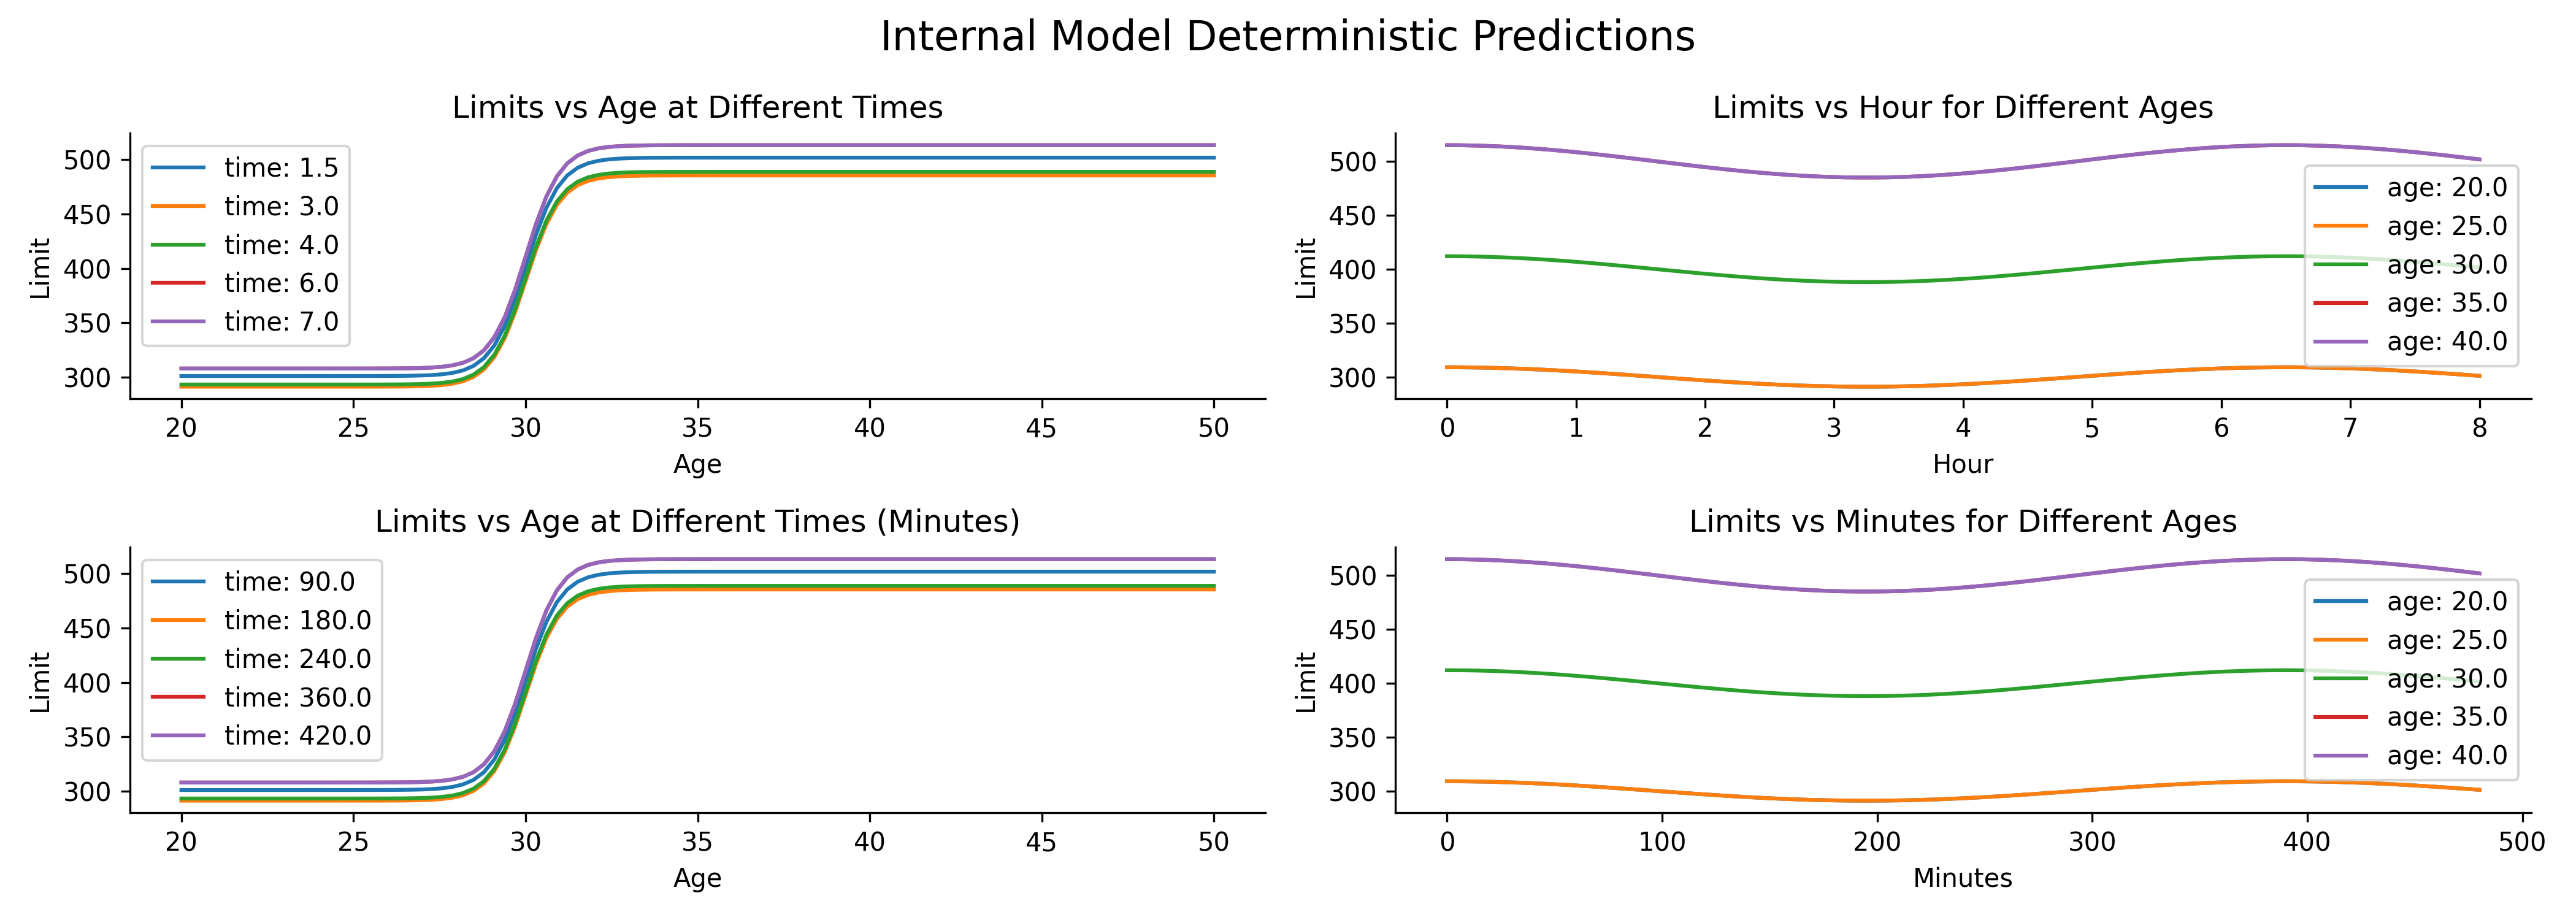

In [3]:
display(Image(filename="dce/internal_model_predictions.png"))

To deploy SearchForExplanation, we add a Bayesian layer, and so the second distiction results a slight change in the distribution of age of the applicants. While times of arrival for simplicity will be modeled using effectively one normal distribution $(4,.9)$ on the hour scal e ($4 \times 60, .9 \times 60$ on the minute scale), we use models with two different priors for age, and the resulting push-forward distributions for the approved credit limit.

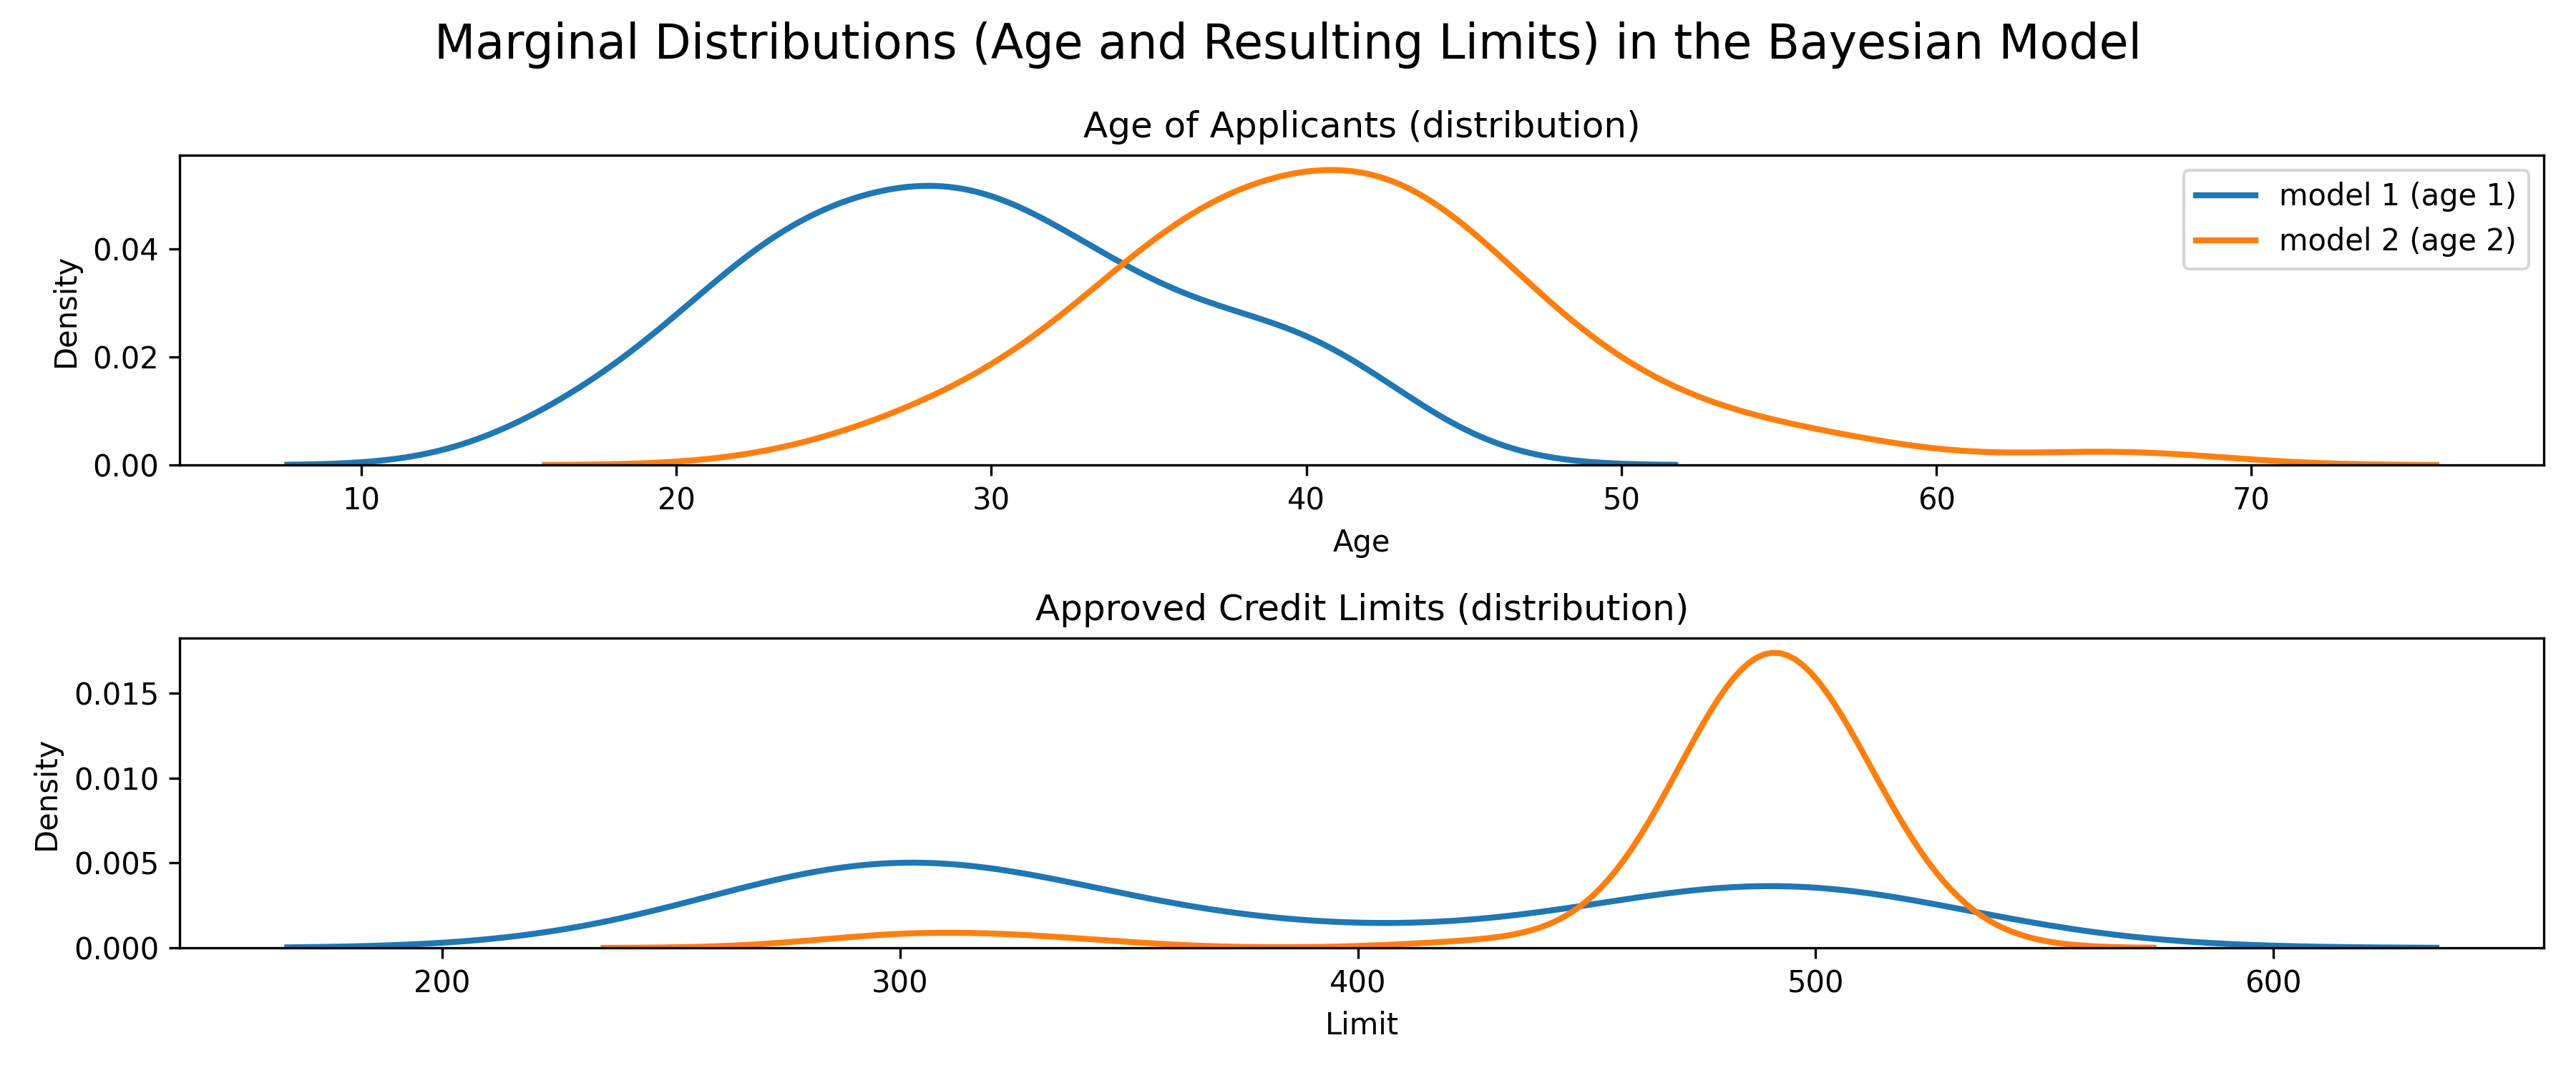

In [4]:
display(Image(filename="dce/marginal_distributions_age_hours.png"))

### <a id='toc1_3_'></a>[Responsibility scores](#toc0_)

We will take a look at the results at two levels of granularity. First, we will assume some specific factual values for the inputs, and sample from the expanded model, inspecting the resulting samples in the necessity and the sufficiency worlds, together with point-wise scores for those samples. The summarized scores (total score) will be the mean of the point-wise scores. This will be done conditioned on a given feature being intervened. So first, we inspect scores resulting from forcing (at least) age to be an active antecedent, and then scores resulting from doing the same for the time of intervention.

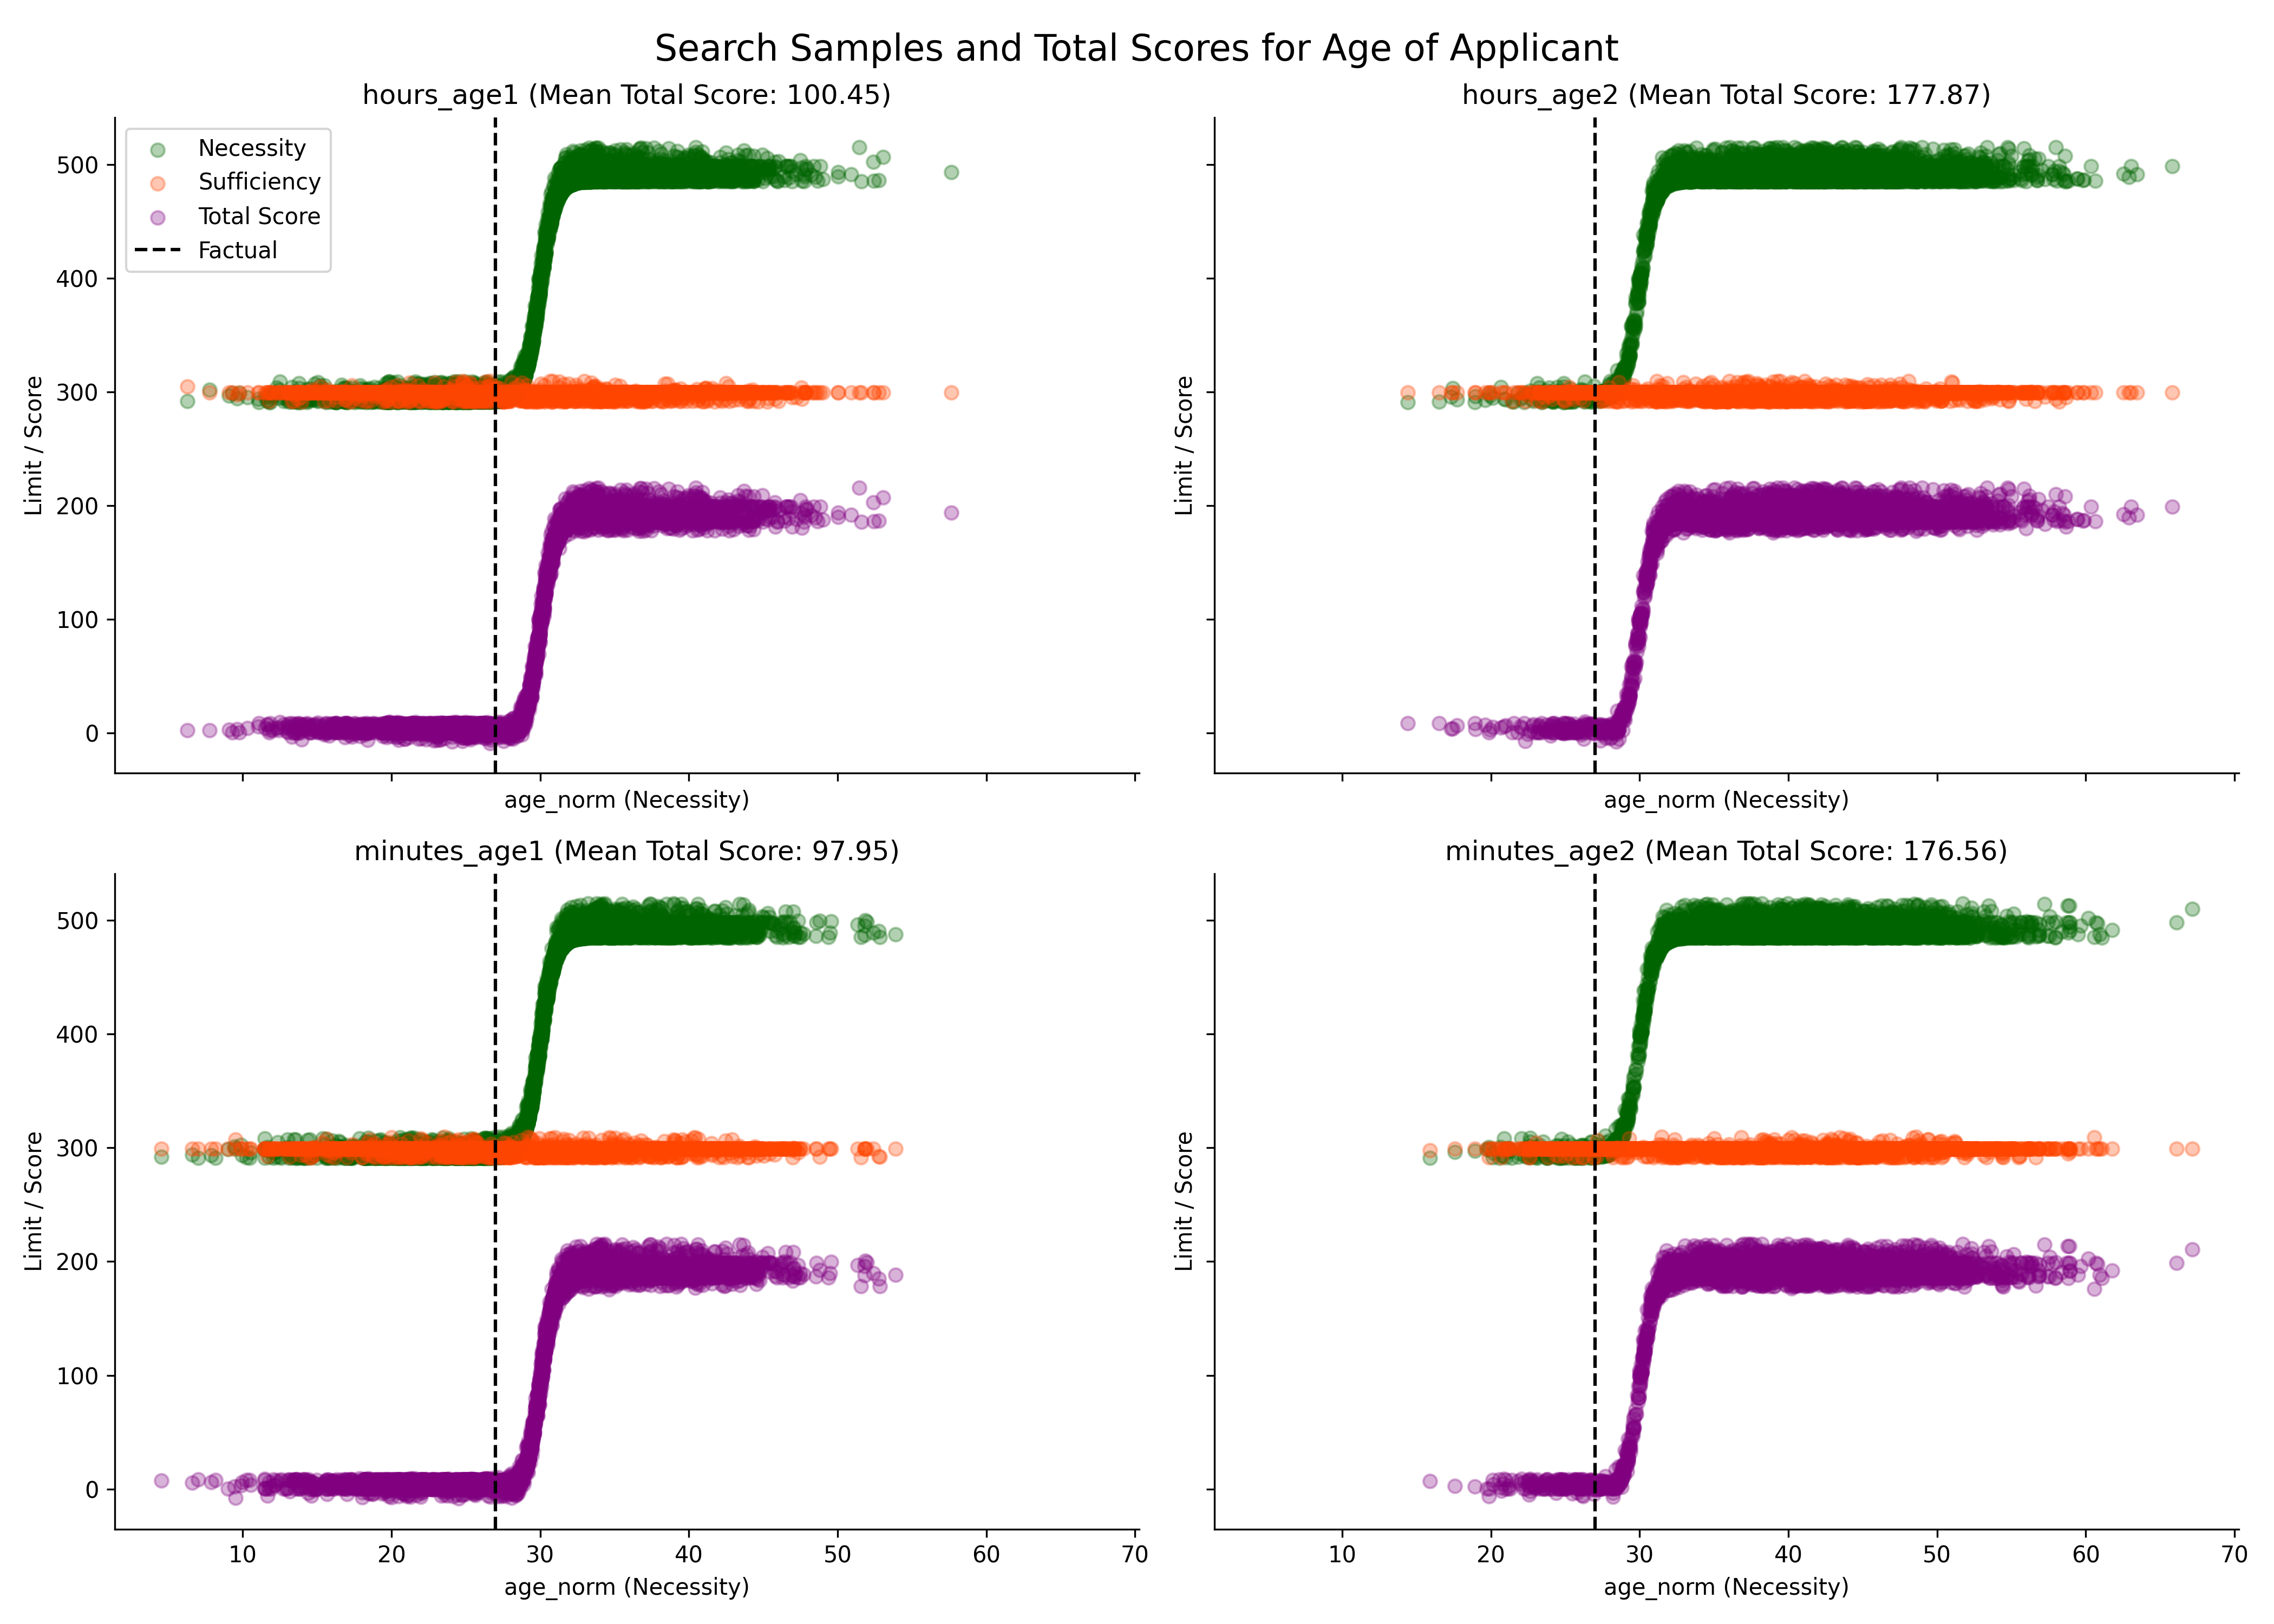

In [5]:
display(Image(filename="dce/search_samples_age_norm.png"))

In the sufficiency worlds the outcome does not change much, but it changes in the necessity world, and the change patters follow roughly the deterministic lines plotted before. The difference between left and right lies in what sampling distribution for Age was used, so the score for a more unusual age from the perspective of the prior is higher. The difference between rows and columns is whether the model using hourly scale or minutes for Time of Application was used, and we observe no difference in the outcome distributions along this axis.

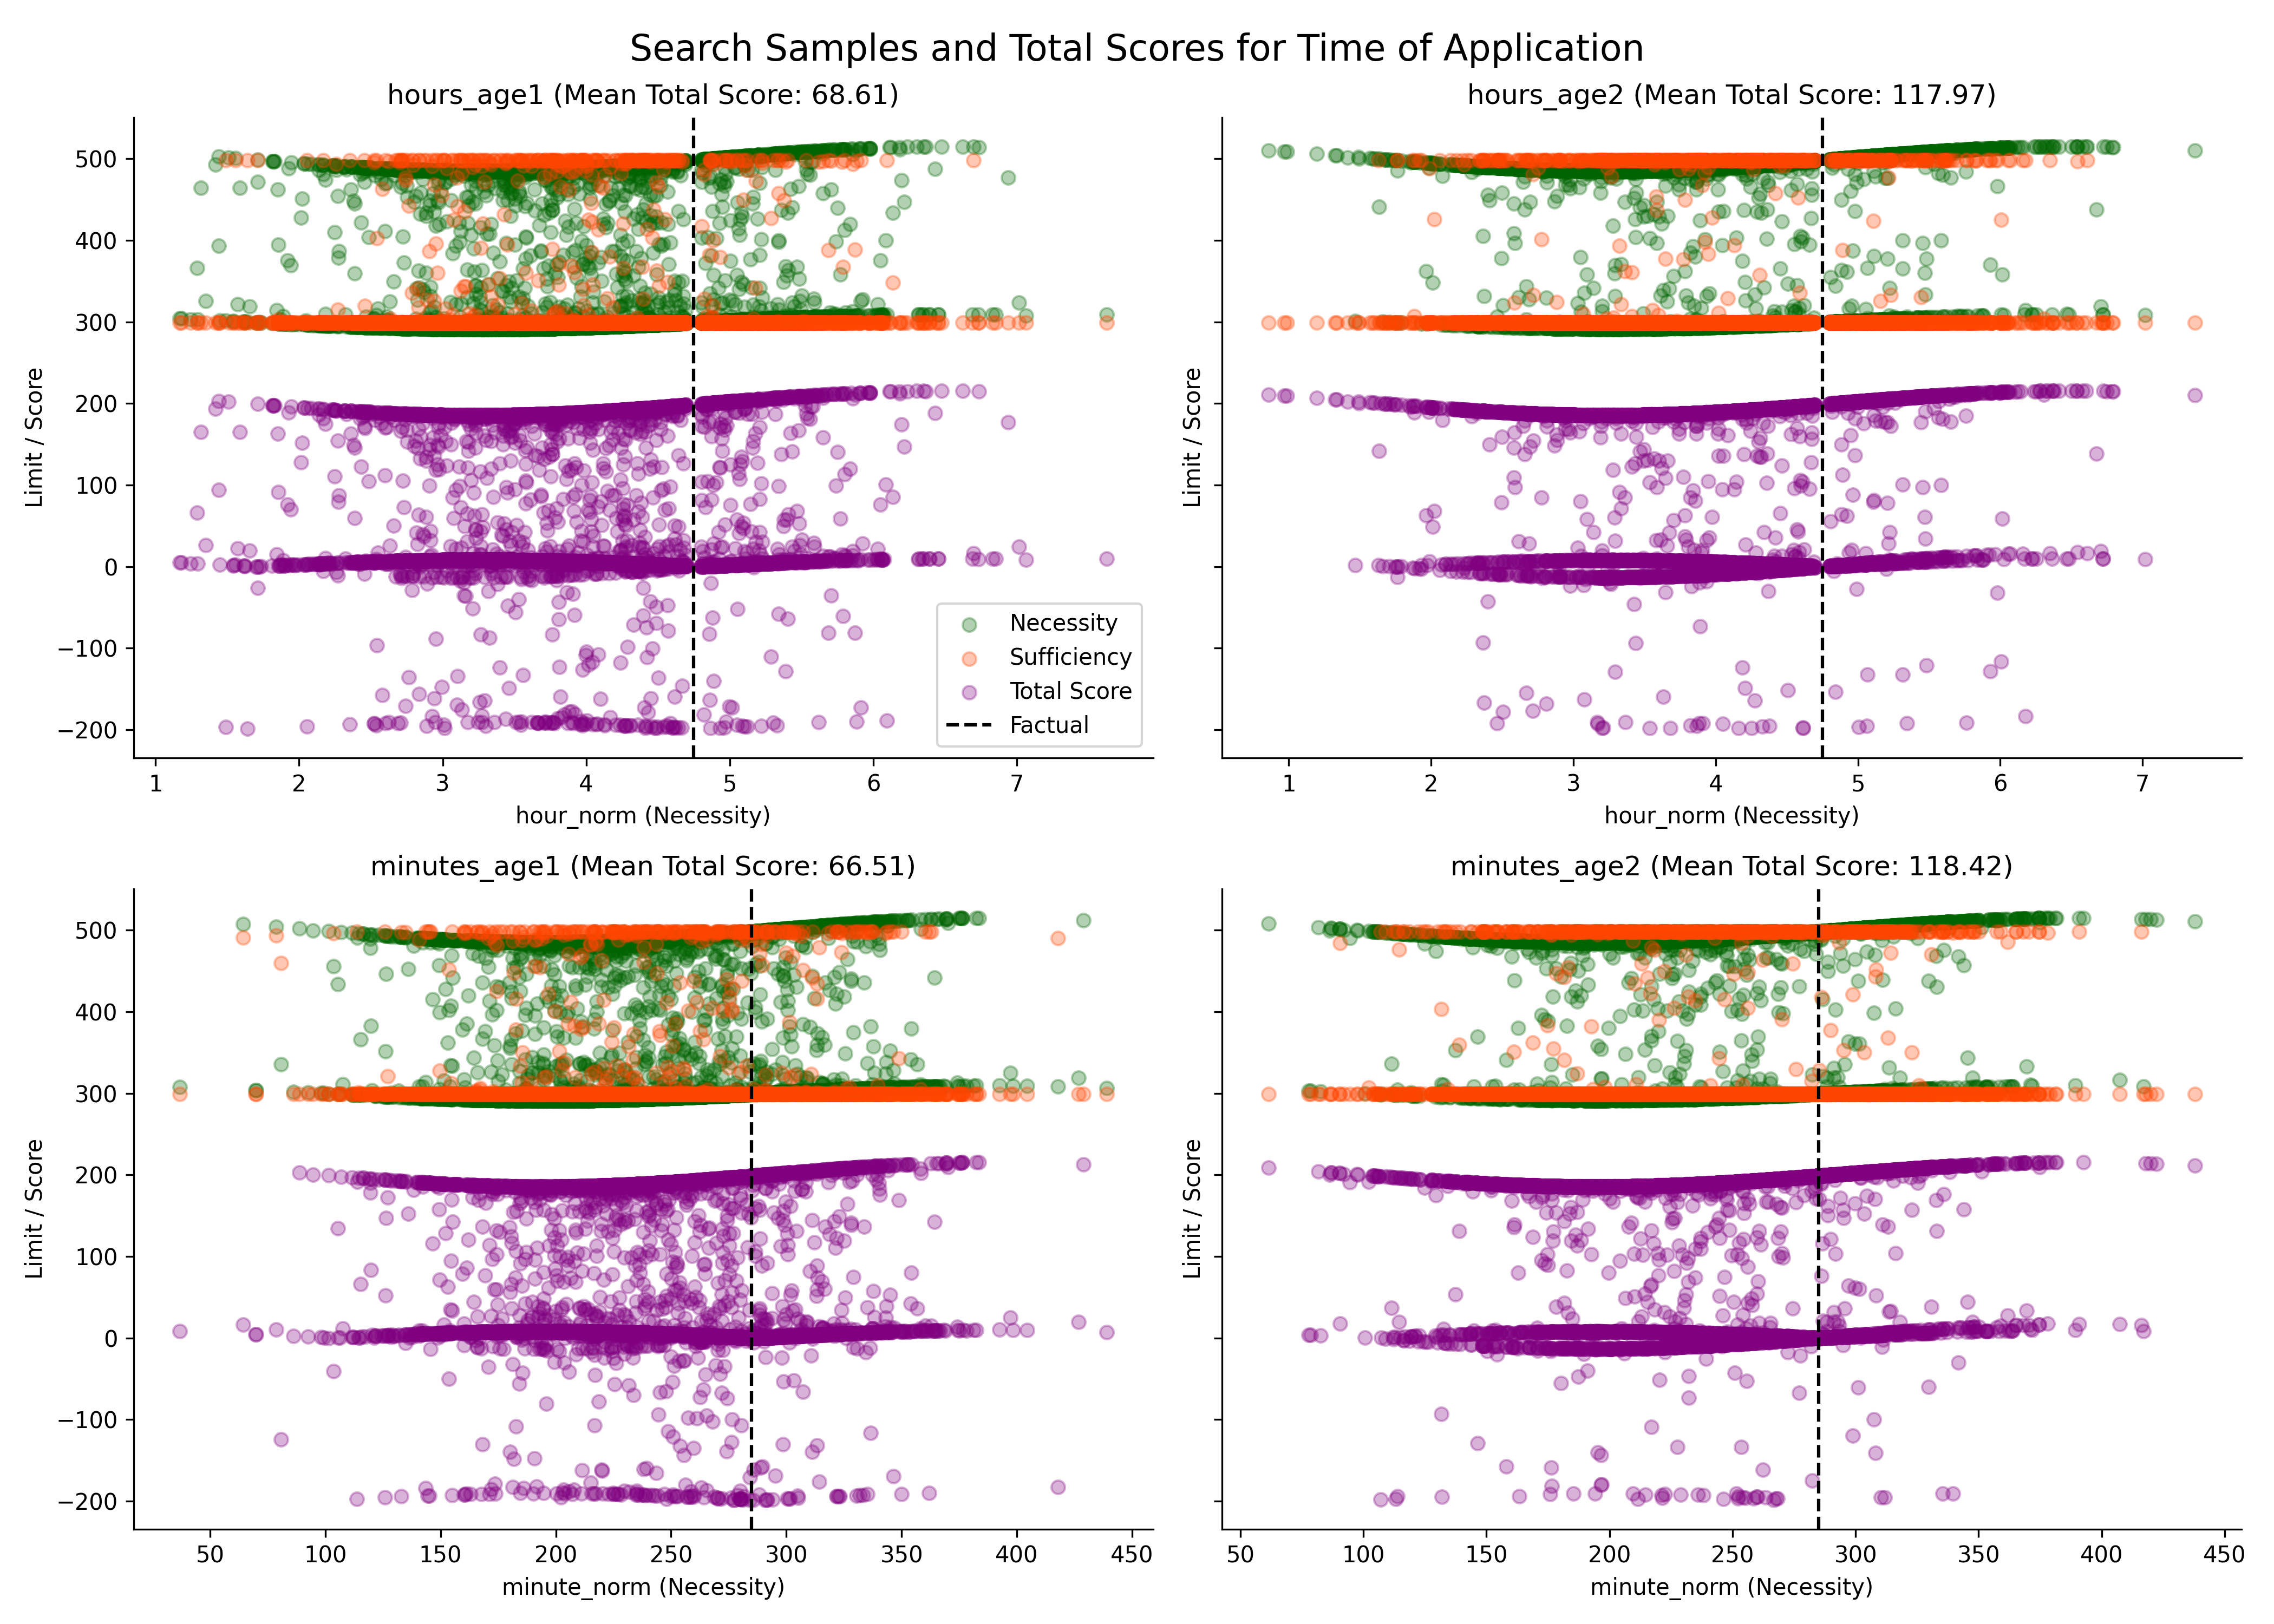

In [6]:
display(Image(filename="dce/search_samples_hour_norm.png"))

Here, the division of plots is analogous. One difference is that even in the sufficiency world the outcomes are sometimes quite different (as in some sampling runs for robustness we also sample Age, and it can have a large impact, so Time of Application is not very sufficient for the approved credit limit). Another observation is that the absolute changes in the outcome are realtively small compared to those involved in the previous plot. Accordingly, the total scores are systematically lower for Time of Application than for Age of Applicant, which is intended and intuitive.

Second, we explore responsibility scores accross a range of inputs on a grid, and do the same for DCE. One observation is that the responsibility score is always higher for age, with scores for individual variables somewhat varying depending on how unusual they are from the perspective of the distributions and what credit limits they lead to in the sufficiency and the necessity world.

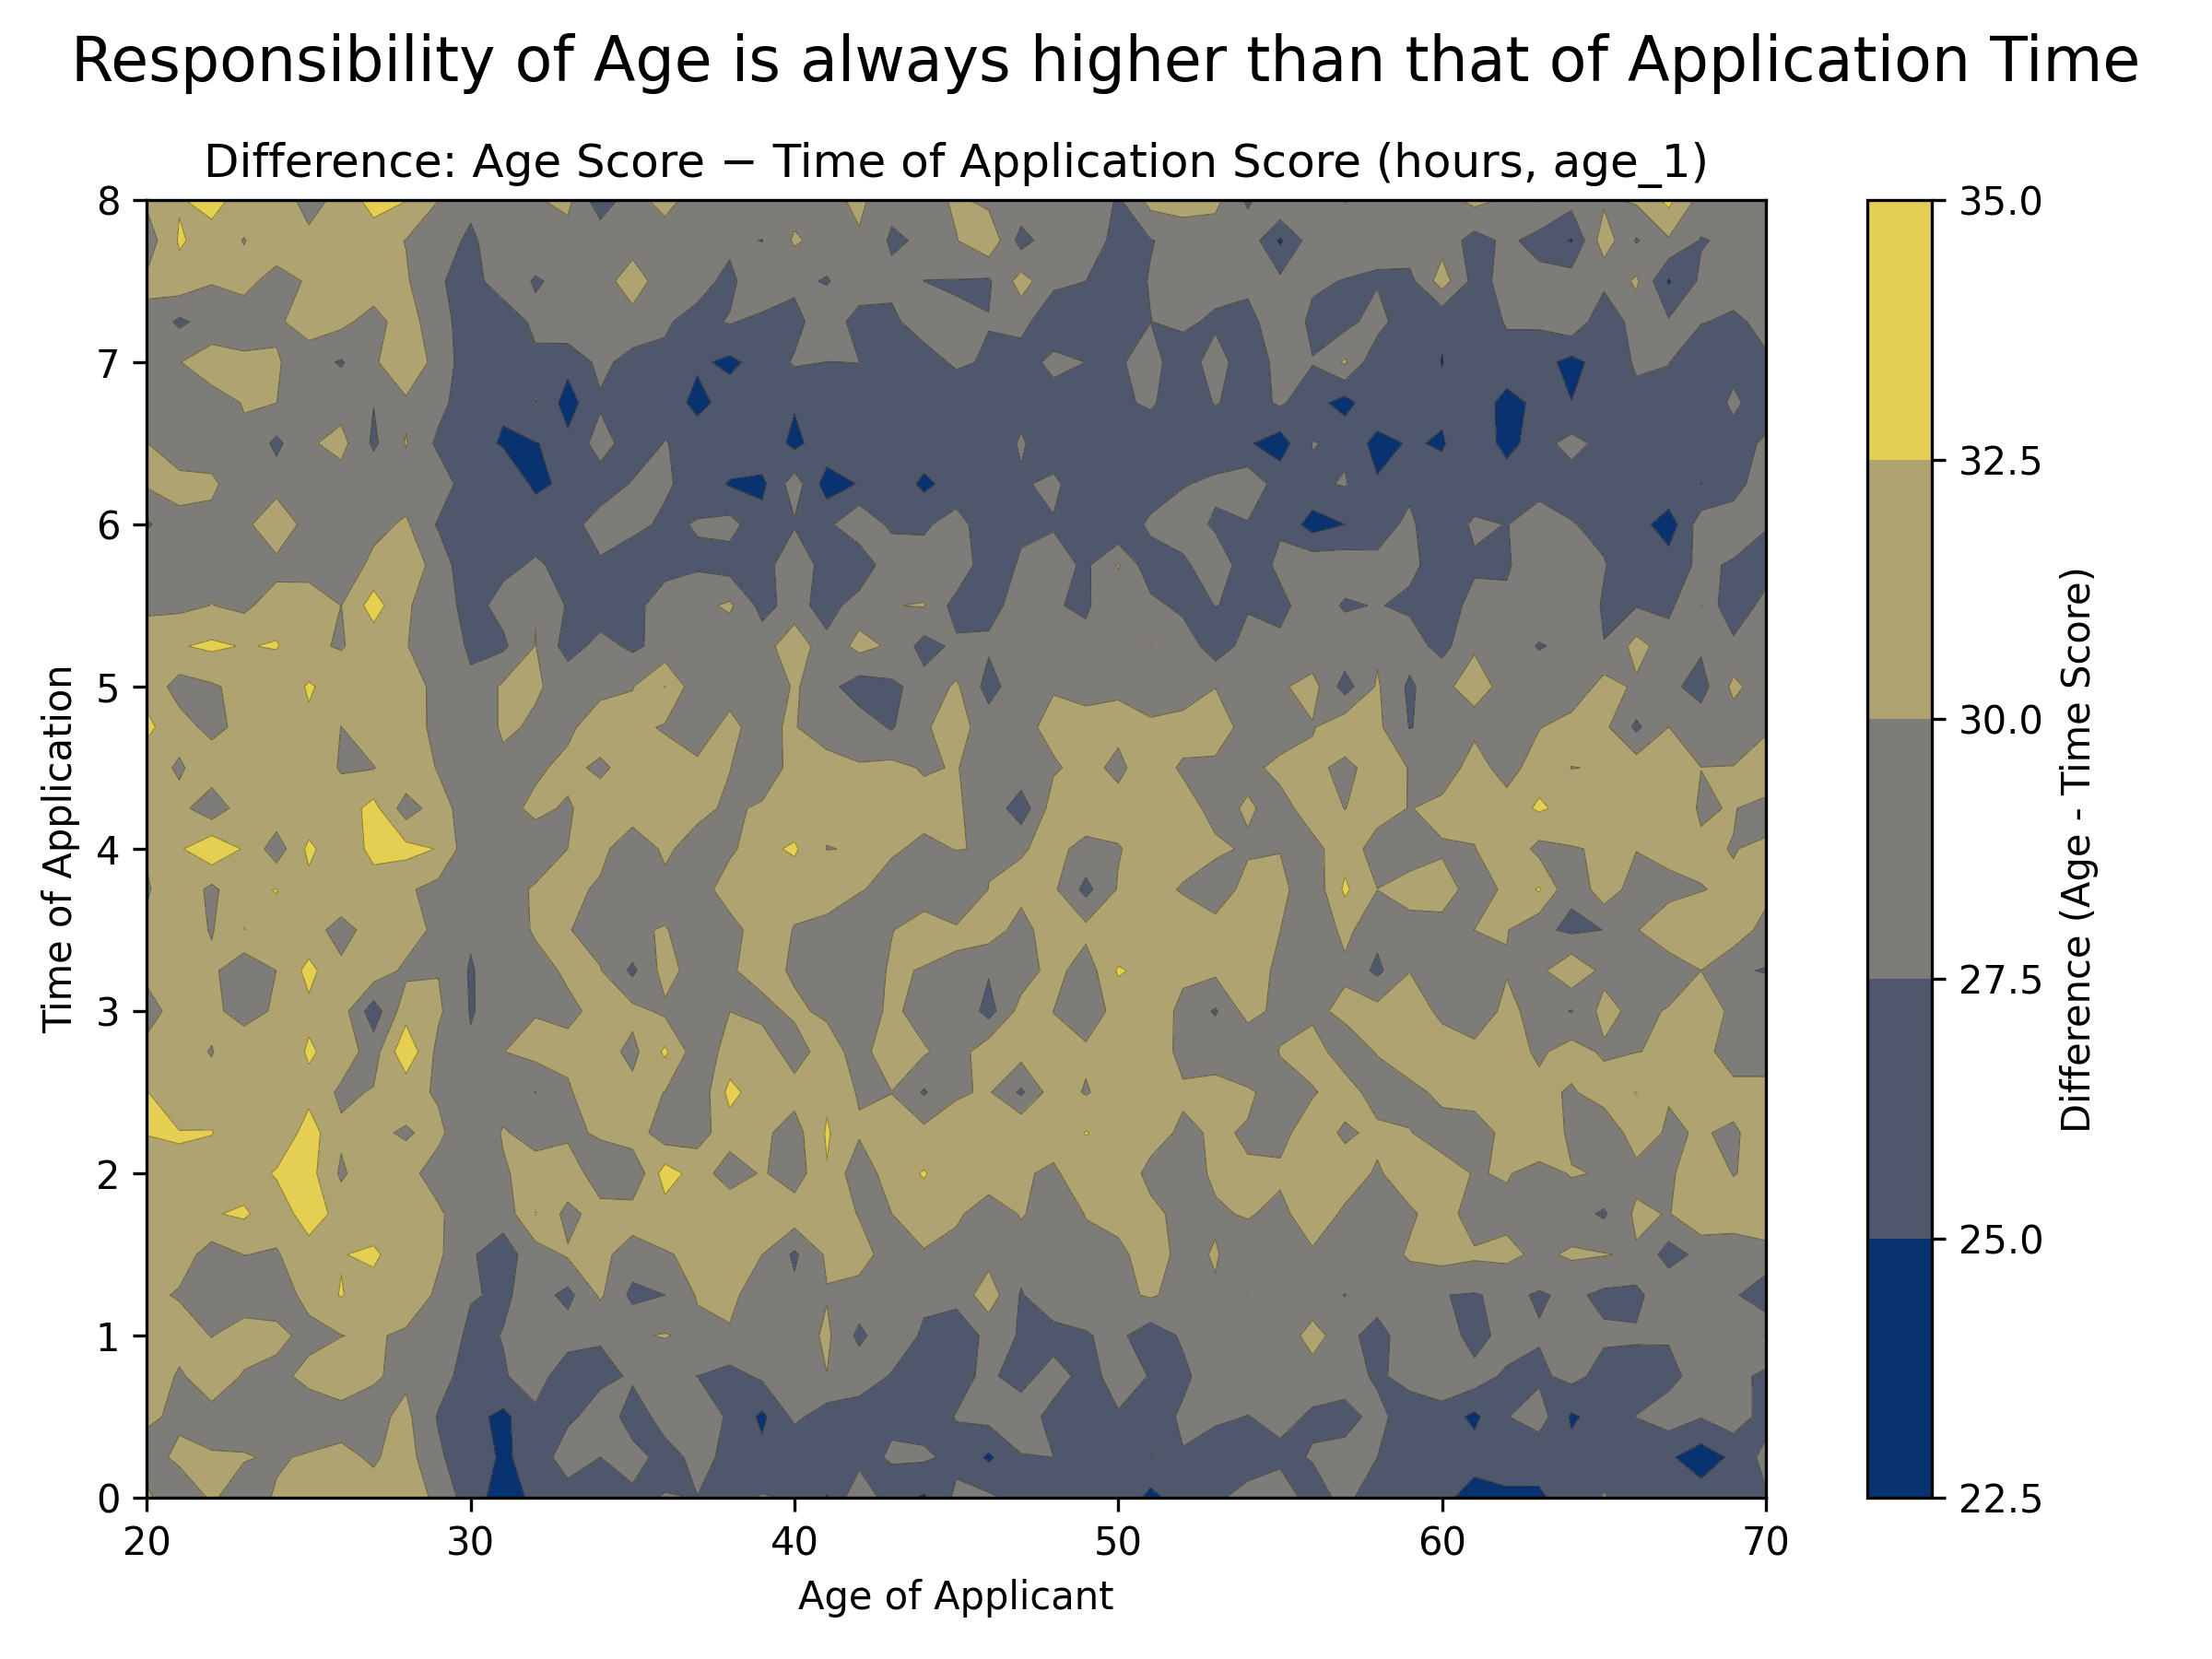

In [7]:
display(Image(filename="dce/contour_diff_hours_age_1.png"))

### <a id='toc1_4_'></a>[Differential causal effects](#toc0_)

In contrast, DCE scores are more diffult to interpret. For one, on the hour scale, DCE for Time of Application is a wave which takes absolute values higher than DCE for Age - so DCE does not capture the intuition that the impact of Age trumps the impact of Time of Application, as changes in the latter only lead to minor differences in the outcome, which a change in Age can have much larger consequence. 

Moreover, when we switch scale to minutes, the DCE scores for Time of Application become relatively flat, which means that the score we assign to Time of Application is highly sensitive to input units.

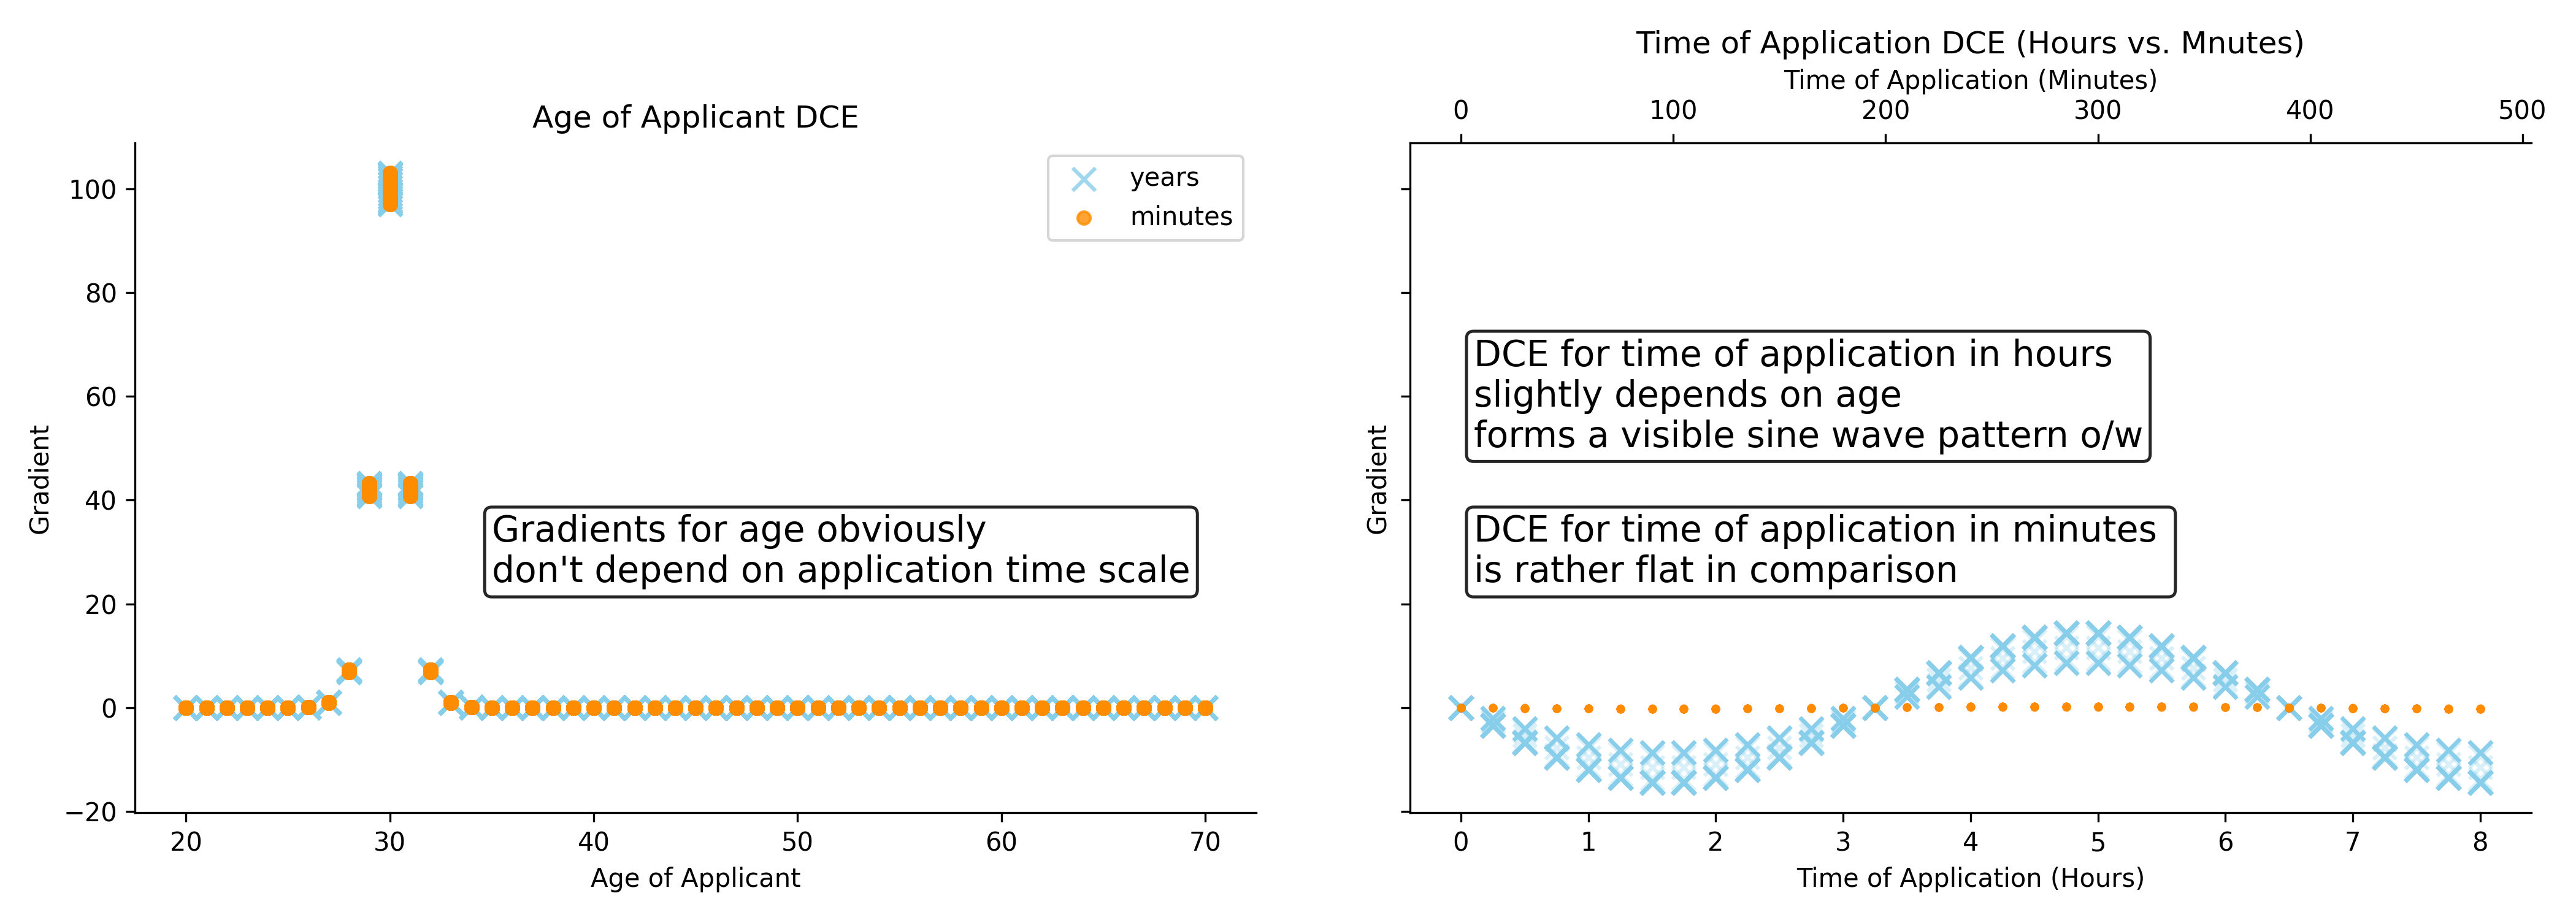

In [8]:
display(Image(filename="dce/dce_age_time_hours_minutes.png"))

## <a id='toc2_'></a>[Code](#toc0_)

### <a id='toc2_1_'></a>[Models](#toc0_)

In [9]:
def internal_model_hours(age_norm: torch.Tensor, hour_norm: torch.Tensor):
    steepness = 2  # smaller -> more gradual, larger -> steeper
    amplitude = 0.03
    peak_hour = 0  # 10 AM peak

    age_scaled = (age_norm - 30) * steepness

    sigmoid_transform = transforms.SigmoidTransform()
    affine_transform = transforms.AffineTransform(300, 200)  # scale=200, loc=300
    transform = transforms.ComposeTransform([sigmoid_transform, affine_transform])

    limit_base = pyro.deterministic("limit_base", transform(age_scaled))

    multiplier = 1.0 + amplitude * torch.sin(
        2 * torch.pi * (hour_norm - peak_hour) / 6.5 + torch.pi / 2
    )
    # move to 0 if between 18 and 9

    limit = pyro.deterministic("limit", multiplier * limit_base)

    return limit


def internal_model_minutes(age_norm: torch.Tensor, minute_norm: torch.Tensor):
    steepness = 2  # smaller -> more gradual, larger -> steeper
    amplitude = 0.03
    peak_minute = 0  # 10 AM peak

    age_scaled = (age_norm - 30) * steepness

    sigmoid_transform = transforms.SigmoidTransform()
    affine_transform = transforms.AffineTransform(300, 200)  # scale=200, loc=300
    transform = transforms.ComposeTransform([sigmoid_transform, affine_transform])

    limit_base = pyro.deterministic("limit_base", transform(age_scaled))

    multiplier = 1.0 + amplitude * torch.sin(
        2 * torch.pi * (minute_norm - peak_minute) / 390 + torch.pi / 2
    )
    # move to 0 if between 18 and 9

    limit = pyro.deterministic("limit", multiplier * limit_base)

    return limit

/tmp/ipykernel_36449/2650591958.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  age_norm=torch.tensor(age_space), hour_norm=torch.tensor(time)
/tmp/ipykernel_36449/2650591958.py:45: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  age_norm=torch.tensor(age_space), minute_norm=torch.tensor(time)


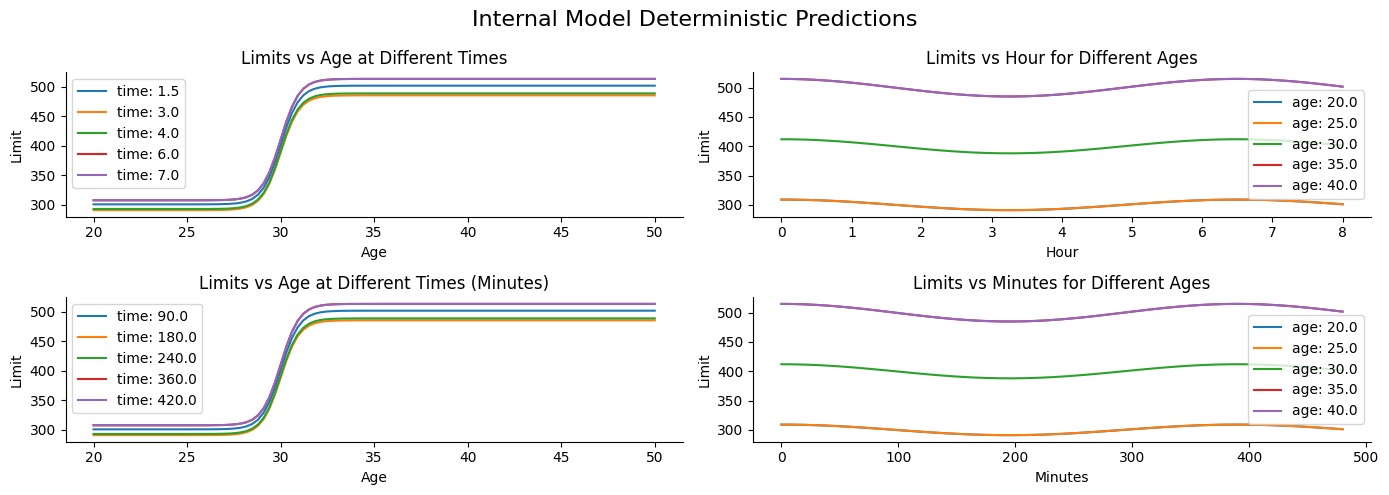

In [10]:
# visualize impacts for the internal model

age_space = torch.linspace(20.0, 50.0, steps=100)
hour_space = torch.linspace(0, 8, steps=100)
minute_space = torch.linspace(0, 8 * 60, steps=100)

fig, axes = plt.subplots(2, 2, figsize=(14, 5))


hours = [1.5, 3.0, 4.0, 6.0, 7.0]
limits = {}
limits_age = {}
for time in hours:
    limits[time] = internal_model_hours(
        age_norm=torch.tensor(age_space), hour_norm=torch.tensor(time)
    ).numpy()
    axes[0, 0].plot(age_space.numpy(), limits[time], label=f"time: {time}")

axes[0, 0].set_xlabel("Age")
axes[0, 0].set_ylabel("Limit")
axes[0, 0].set_title("Limits vs Age at Different Times")
axes[0, 0].legend()
sns.despine(ax=axes[0, 0])

ages = [20.0, 25.0, 30.0, 35.0, 40.0]
for _age in ages:
    limits_age[_age] = internal_model_hours(
        age_norm=torch.tensor(_age), hour_norm=hour_space
    ).numpy()
    axes[0, 1].plot(hour_space.numpy(), limits_age[_age], label=f"age: {_age}")

axes[0, 1].set_xlabel("Hour")
axes[0, 1].set_ylabel("Limit")
axes[0, 1].set_title("Limits vs Hour for Different Ages")
axes[0, 1].legend()
sns.despine(ax=axes[0, 1])

minutes = [h * 60 for h in hours]
limits_minutes = {}
limits_minutes_age = {}


for time in minutes:
    limits_minutes[time] = internal_model_minutes(
        age_norm=torch.tensor(age_space), minute_norm=torch.tensor(time)
    ).numpy()
    axes[1, 0].plot(age_space.numpy(), limits_minutes[time], label=f"time: {time}")

axes[1, 0].set_xlabel("Age")
axes[1, 0].set_ylabel("Limit")
axes[1, 0].set_title("Limits vs Age at Different Times (Minutes)")
axes[1, 0].legend()
sns.despine(ax=axes[1, 0])

for _age in ages:
    limits_minutes_age[_age] = internal_model_minutes(
        age_norm=torch.tensor(_age), minute_norm=minute_space
    ).numpy()
    axes[1, 1].plot(
        minute_space.numpy(), limits_minutes_age[_age], label=f"age: {_age}"
    )

axes[1, 1].set_xlabel("Minutes")
axes[1, 1].set_ylabel("Limit")
axes[1, 1].set_title("Limits vs Minutes for Different Ages")
axes[1, 1].legend()
sns.despine(ax=axes[1, 1])


plt.suptitle("Internal Model Deterministic Predictions", fontsize=16)

plt.tight_layout()
file_path = "dce/internal_model_predictions.png"
plt.savefig(file_path, dpi=300)

plt.show()

# The plots for two scales should be qualitatively the same
for key in limits.keys():
    limits_array = limits[key]
    limits_minutes_array = limits_minutes[key * 60]
    np.testing.assert_allclose(limits_array, limits_minutes_array, rtol=1e-5)

for key in limits_age.keys():
    limits_array = limits_age[key]
    limits_minutes_array = limits_minutes_age[key]
    np.testing.assert_allclose(limits_array, limits_minutes_array, rtol=1e-5)

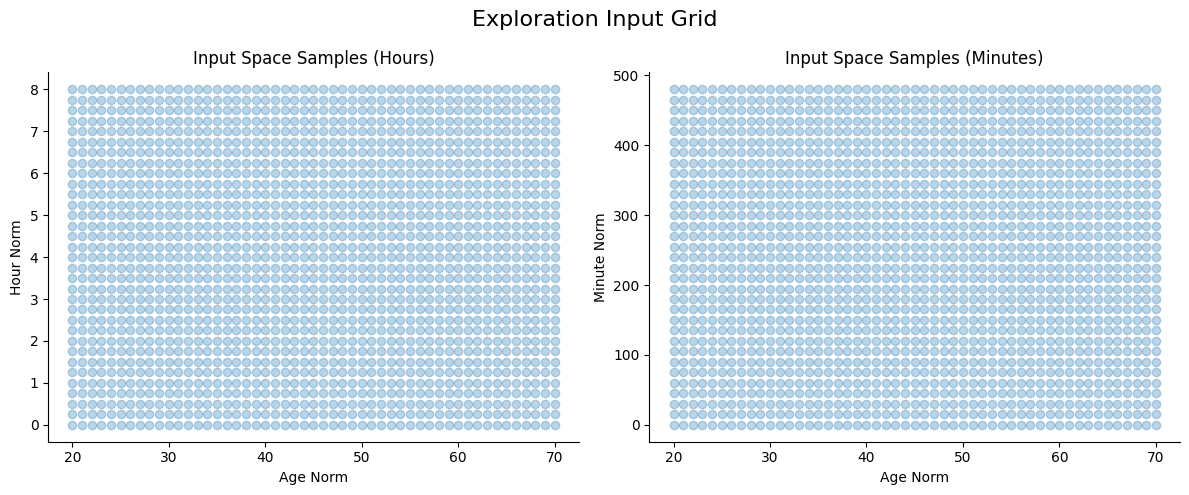

synth limits hours shape torch.Size([1683, 1, 1])
synth limits minutes shape torch.Size([1683, 1, 1])


In [11]:
# make synthetic data for future reference and
# build grids for further exploration

ages = torch.linspace(20.0, 70.0, steps=51)  # type: ignore
hours = torch.linspace(0.0, 8.0, steps=33)  # type: ignore
minutes = torch.linspace(0.0, 8.0 * 60, steps=33)  # type: ignore

# Build meshgrid
A, H = torch.meshgrid(ages, hours, indexing="ij")  # type: ignore
Am, M = torch.meshgrid(ages, minutes, indexing="ij")  # type: ignore

# Flatten and reshape to [N, 1, 1]
A_flat = A.reshape(-1, 1, 1)  # [51*33, 1, 1]
H_flat = H.reshape(-1, 1, 1)  # [51*33, 1, 1]

Am_flat = Am.reshape(-1, 1, 1)
M_flat = M.reshape(-1, 1, 1)

inputs_of_interest = {"age_norm": A_flat, "hour_norm": H_flat}
inputs_of_interest_minutes = {"age_norm": Am_flat, "minute_norm": M_flat}


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(
    inputs_of_interest["age_norm"].numpy().flatten(),
    inputs_of_interest["hour_norm"].numpy().flatten(),
    alpha=0.3,
)
axes[0].set_xlabel("Age Norm")
axes[0].set_ylabel("Hour Norm")
axes[0].set_title("Input Space Samples (Hours)")
sns.despine(ax=axes[0])

axes[1].scatter(
    inputs_of_interest_minutes["age_norm"].numpy().flatten(),
    inputs_of_interest_minutes["minute_norm"].numpy().flatten(),
    alpha=0.3,
)
axes[1].set_xlabel("Age Norm")
axes[1].set_ylabel("Minute Norm")
axes[1].set_title("Input Space Samples (Minutes)")
sns.despine(ax=axes[1])

plt.suptitle("Exploration Input Grid", fontsize=16)

plt.tight_layout()
plt.show()

# These are the evaluation grids
synthetic_limits_hours = internal_model_hours(**inputs_of_interest)
synthetic_limits_minutes = internal_model_minutes(**inputs_of_interest_minutes)


observations_dict_hours = {
    "continuous": {
        "limit": synthetic_limits_hours,
        "age_norm": inputs_of_interest["age_norm"],
        "hour_norm": inputs_of_interest["hour_norm"],
    },
    "categorical": {},
}

observations_dict_minutes = {
    "continuous": {
        "limit": synthetic_limits_minutes,
        "age_norm": inputs_of_interest_minutes["age_norm"],
        "minute_norm": inputs_of_interest_minutes["minute_norm"],
    },
    "categorical": {},
}


kwargs_iterable_hours = [
    {"observations_dict_hours": observations_dict_hours, "n_size": n_size}
]
kwargs_iterable_minutes = [
    {"observations_dict_minutes": observations_dict_minutes, "n_size": n_size}
]

print("synth limits hours shape", synthetic_limits_hours.shape)
print("synth limits minutes shape", synthetic_limits_minutes.shape)


n_size = 1

In [12]:
# now add the uncertainty layer

AGE_MEAN_1 = 30.0
AGE_MEAN_2 = 40.0
AGE_STD = 7.0

HOUR_MEAN = 4.0
HOUR_STD = 0.9

MINUTE_MEAN = HOUR_MEAN * 60
MINUTE_STD = HOUR_STD * 60


def make_wrapped_model(
    internal_model,
    latent_name,
    latent_mean,
    latent_std,
    default_AGE_MEAN,
):
    """
    Creates a Pyro model wrapper with a configurable default AGE_MEAN.
    """

    def model(
        kwargs_iterable=[
            {"observations_dict": None, "n_size": n_size},
            dict(),
            dict(),
        ],
        AGE_MEAN=default_AGE_MEAN,  # <- default baked in here
    ):
        batch_size = kwargs_iterable[0]["n_size"]

        with pyro.plate("sample", size=batch_size, dim=-3):
            age_norm = pyro.sample("age_norm", dist.Normal(AGE_MEAN, AGE_STD))
            latent = pyro.sample(latent_name, dist.Normal(latent_mean, latent_std))

        return internal_model(age_norm=age_norm, **{latent_name: latent})

    return model


wrapped_hours_age1 = make_wrapped_model(
    internal_model=internal_model_hours,
    latent_name="hour_norm",
    latent_mean=HOUR_MEAN,
    latent_std=HOUR_STD,
    default_AGE_MEAN=AGE_MEAN_1,
)

wrapped_hours_age2 = make_wrapped_model(
    internal_model=internal_model_hours,
    latent_name="hour_norm",
    latent_mean=HOUR_MEAN,
    latent_std=HOUR_STD,
    default_AGE_MEAN=AGE_MEAN_2,
)

wrapped_minutes_age1 = make_wrapped_model(
    internal_model=internal_model_minutes,
    latent_name="minute_norm",
    latent_mean=MINUTE_MEAN,
    latent_std=MINUTE_STD,
    default_AGE_MEAN=AGE_MEAN_1,
)

wrapped_minutes_age2 = make_wrapped_model(
    internal_model=internal_model_minutes,
    latent_name="minute_norm",
    latent_mean=MINUTE_MEAN,
    latent_std=MINUTE_STD,
    default_AGE_MEAN=AGE_MEAN_2,
)

In [13]:
# run the wrapped models with tracing
# take a look at the uncertainties


def run_model_with_trace(model, kwargs_iterable, sample_size):
    with pyro.plate("samples", size=sample_size, dim=-4):
        with pyro.poutine.trace() as tr:
            result = model(kwargs_iterable=kwargs_iterable)
    return tr, result


models = {
    "hours_age1": wrapped_hours_age1,
    "hours_age2": wrapped_hours_age2,
    "minutes_age1": wrapped_minutes_age1,
    "minutes_age2": wrapped_minutes_age2,
}

kwargs_map = {
    "hours_age1": kwargs_iterable_hours,
    "hours_age2": kwargs_iterable_hours,
    "minutes_age1": kwargs_iterable_minutes,
    "minutes_age2": kwargs_iterable_minutes,
}


traces = {}
results = {}

for name, model in models.items():
    tr, res = run_model_with_trace(model, kwargs_map[name], sample_size)
    traces[name] = tr
    results[name] = res

In [14]:
def plot_traces_hours_minutes_kde(
    traces_hours: dict,
    traces_minutes: dict,
    keys_hours=["age_norm", "hour_norm", "limit"],
    keys_minutes=["age_norm", "minute_norm", "limit"],
):
    """
    Same as your histogram function, but plots KDE density curves instead.
    """

    fig, axes = plt.subplots(2, len(keys_hours), figsize=(16, 8))

    # ----- ROW 0: HOURS -----
    for col, key in enumerate(keys_hours):
        ax = axes[0, col]
        for label, trace in traces_hours.items():
            values = trace.trace.nodes[key]["value"].detach().cpu().numpy().flatten()

            sns.kdeplot(
                values,
                ax=ax,
                label=f"{label}",
                linewidth=2,
            )

        ax.set_title(f"{key} (hours)")
        ax.set_xlabel(key)
        ax.set_ylabel("Density")
        ax.legend()
        sns.despine(ax=ax)

    # ----- ROW 1: MINUTES -----
    for col, key in enumerate(keys_minutes):
        ax = axes[1, col]
        for label, trace in traces_minutes.items():
            values = trace.trace.nodes[key]["value"].detach().cpu().numpy().flatten()

            sns.kdeplot(
                values,
                ax=ax,
                label=f"{label}",
                linewidth=2,
            )

        ax.set_title(f"{key} (minutes)")
        ax.set_xlabel(key)
        ax.set_ylabel("Density")
        ax.legend()
        sns.despine(ax=ax)

    plt.suptitle("Marginal Distributions in the Bayesian Model", fontsize=16)
    plt.tight_layout()
    plt.show()

In [15]:
traces["hours_age2"].trace.nodes.keys()

odict_keys(['sample', 'age_norm', 'hour_norm', 'limit_base', 'limit'])

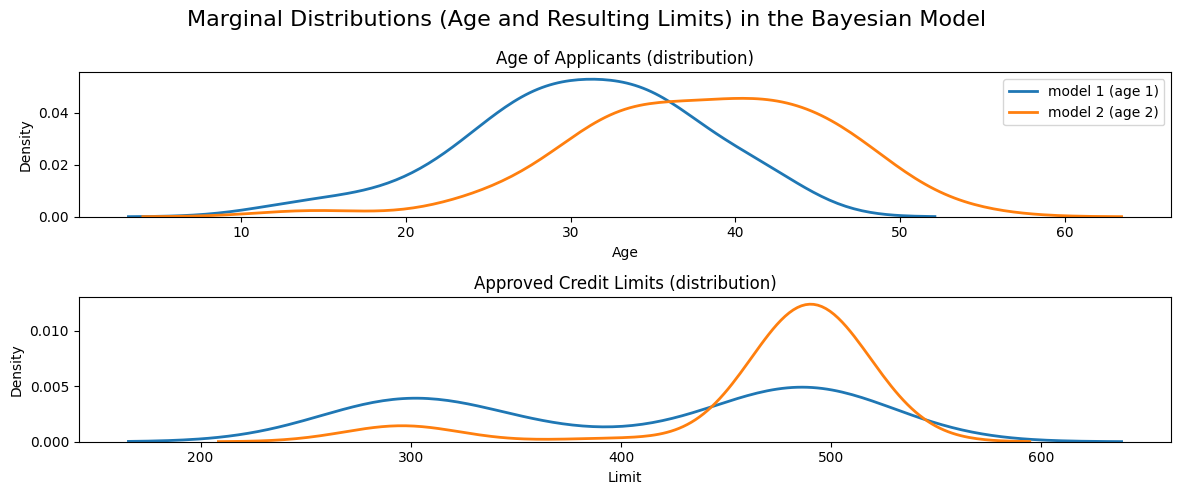

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5))  # <-- create one axes


traces_hours = {
    "model 1 (age 1)": traces["hours_age1"],
    "model 2 (age 2)": traces["hours_age2"],
}


for label, trace in traces_hours.items():
    values = trace.trace.nodes["age_norm"]["value"].detach().cpu().numpy().flatten()

    sns.kdeplot(
        values,
        ax=axes[0],
        label=f"{label}",
        linewidth=2,
    )

axes[0].set_title("Age of Applicants (distribution)")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Density")
axes[0].legend()

for label, trace in traces_hours.items():
    values = trace.trace.nodes["limit"]["value"].detach().cpu().numpy().flatten()

    sns.kdeplot(
        values,
        ax=axes[1],
        label=f"{label}",
        linewidth=2,
    )

axes[1].set_title("Approved Credit Limits (distribution)")
axes[1].set_xlabel("Limit")
axes[1].set_ylabel("Density")


plt.suptitle(
    "Marginal Distributions (Age and Resulting Limits) in the Bayesian Model",
    fontsize=16,
)
plt.tight_layout()
fig_path = "dce/marginal_distributions_age_hours.png"
plt.savefig(fig_path, dpi=300)
plt.show()

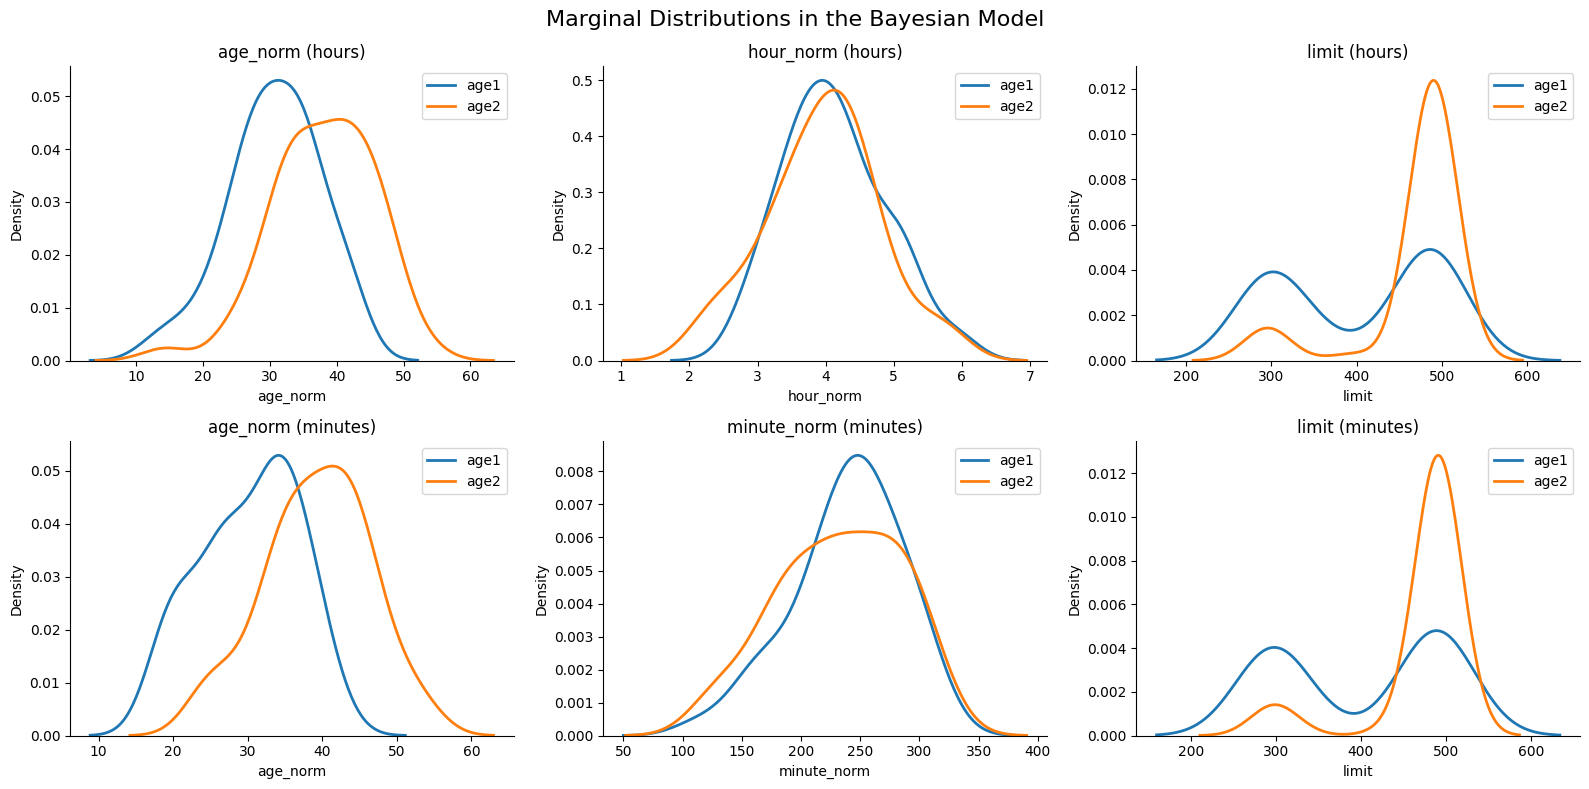

In [17]:
traces_hours = {
    "age1": traces["hours_age1"],
    "age2": traces["hours_age2"],
}

traces_minutes = {
    "age1": traces["minutes_age1"],
    "age2": traces["minutes_age2"],
}

plot_traces_hours_minutes_kde(traces_hours, traces_minutes)

### <a id='toc2_2_'></a>[Search For Explanation](#toc0_)

In [18]:
def make_searchable_model(
    wrapped_model,
    sites_of_interest,
    suspects,
    outcome_variable="limit",
):
    return SearchableModel(
        structured_model=wrapped_model,
        sites_of_interest=sites_of_interest,
        suspects=suspects,
        outcome_variable=outcome_variable,
    )


model_configs = {
    "hours_age1": {
        "wrapped": wrapped_hours_age1,
        "sites": ["age_norm", "hour_norm"],
        "suspects": ["age_norm", "hour_norm"],
    },
    "hours_age2": {
        "wrapped": wrapped_hours_age2,
        "sites": ["age_norm", "hour_norm"],
        "suspects": ["age_norm", "hour_norm"],
    },
    "minutes_age1": {
        "wrapped": wrapped_minutes_age1,
        "sites": ["age_norm", "minute_norm"],
        "suspects": ["age_norm", "minute_norm"],
    },
    "minutes_age2": {
        "wrapped": wrapped_minutes_age2,
        "sites": ["age_norm", "minute_norm"],
        "suspects": ["age_norm", "minute_norm"],
    },
}

obs_map = {
    "hours_age1": observations_dict_hours,
    "hours_age2": observations_dict_hours,
    "minutes_age1": observations_dict_minutes,
    "minutes_age2": observations_dict_minutes,
}

searchable_models = {}

for name, cfg in model_configs.items():
    searchable_models[name] = make_searchable_model(
        wrapped_model=cfg["wrapped"],
        sites_of_interest=cfg["sites"],
        suspects=cfg["suspects"],
        outcome_variable="limit",
    )

samplers = {}

for name, searchable in searchable_models.items():
    samplers[name] = ThinSearchSampler(
        structured_model=searchable,
        conditioned_alternatives=True,
        factual_exclusion=True,
    )


cache_file = "search_results.pkl"

# Load cache if it exists
if os.path.exists(cache_file):
    with open(cache_file, "rb") as f:
        search_results = pickle.load(f)
else:
    search_results = {}


for name, sampler in samplers.items():
    if name not in search_results:
        print(f"Sampling for {name}...")
        search_results[name] = sampler.sample(obs_map[name], num_samples=num_search_samples)
    else:
        print(f"Using cached result for {name}")

# Save updated cache
with open(cache_file, "wb") as f:  # type: ignore
    pickle.dump(search_results, f)

Using cached result for hours_age1
Using cached result for hours_age2
Using cached result for minutes_age1
Using cached result for minutes_age2


In [19]:
suspects_map = {
    "hours_age1": ["age_norm", "hour_norm"],
    "hours_age2": ["age_norm", "hour_norm"],
    "minutes_age1": ["age_norm", "minute_norm"],
    "minutes_age2": ["age_norm", "minute_norm"],
}

factuals_map = {
    "hours_age1": synthetic_limits_hours,
    "hours_age2": synthetic_limits_hours,
    "minutes_age1": synthetic_limits_minutes,
    "minutes_age2": synthetic_limits_minutes,
}


def compute_suspect_scores(
    results_dict,  # output from search_sampler.sample
    suspects,  # list of suspect variable names
    factual_outcomes,  # e.g., synthetic_limits_hours or synthetic_limits_minutes
):
    conditioned_samples = {}
    suspect_scores = {}

    for suspect in suspects:
        conditioned_samples[suspect] = condition_on_interventional_regime(
            results_dictionary=results_dict,
            reference_variable_names=[suspect],
            antecedent_regimes={suspect: True},
            witness_regimes={suspect: False},
        )

        limit_suff = conditioned_samples[suspect]["regime_sufficiency"][
            "limit"
        ].detach()
        limit_nec = conditioned_samples[suspect]["regime_necessity"]["limit"]

        scores = abs_diff_score(
            suff_outcomes=limit_suff,
            nec_outcomes=limit_nec,
            factual_outcomes=factual_outcomes,
        )

        suspect_scores[suspect] = scores

    return suspect_scores


all_suspect_scores = {}

for name, results in search_results.items():
    all_suspect_scores[name] = compute_suspect_scores(
        results_dict=results,
        suspects=suspects_map[name],
        factual_outcomes=factuals_map[name],
    )

In [20]:
all_conditioned_samples = {}

for name, results in search_results.items():
    suspects = suspects_map[name]
    conditioned_samples = {}
    for suspect in suspects:
        conditioned_samples[suspect] = condition_on_interventional_regime(
            results_dictionary=results,
            reference_variable_names=[suspect],
            antecedent_regimes={suspect: True},
            witness_regimes={suspect: False},
        )
    all_conditioned_samples[name] = conditioned_samples

obs_map_for_plotting = {
    "hours_age1": observations_dict_hours,
    "hours_age2": observations_dict_hours,
    "minutes_age1": observations_dict_minutes,
    "minutes_age2": observations_dict_minutes,
}

### <a id='toc2_3_'></a>[Inspect responsibility scores across models](#toc0_)

In [21]:
def plot_interventional_scatter(
    all_conditioned_samples,  # dict: {"model_name": conditioned_samples}
    all_suspect_scores,  # dict: {"model_name": suspect_scores}
    factuals,  # dict: {"model_name": {"age_norm": val, "hour_norm"/"minute_norm": val}}
    index_of_interest=0,
    suspect_of_interest="age_norm",
    feature_name="Age of Applicant",
    sharex=True,
):
    """
    Plots a 2x2 grid of scatter plots for interventional regimes:
    - row 0: hours models
    - row 1: minutes models
    - col 0: AGE_MEAN_1
    - col 1: AGE_MEAN_2

    Handles age_norm, hour_norm, and minute_norm automatically.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=sharex, sharey=True)
    axes = axes.reshape(2, 2)

    # Map models to rows and columns
    model_grid = [
        ["hours_age1", "hours_age2"],
        ["minutes_age1", "minutes_age2"],
    ]

    # Map default latent per model if suspect_of_interest is not present
    default_suspect_map = {
        "hours_age1": "hour_norm",
        "hours_age2": "hour_norm",
        "minutes_age1": "minute_norm",
        "minutes_age2": "minute_norm",
    }

    for row, row_models in enumerate(model_grid):
        for col, model_name in enumerate(row_models):
            ax = axes[row, col]

            conditioned = all_conditioned_samples[model_name]
            scores = all_suspect_scores[model_name]

            # Use provided suspect_of_interest if it exists, else fall back to default
            suspect = (
                suspect_of_interest
                if suspect_of_interest in conditioned
                else default_suspect_map[model_name]
            )

            factual = factuals[model_name][suspect]

            # Extract arrays
            nec_vals = conditioned[suspect]["regime_necessity"][suspect][
                :, index_of_interest, ...
            ]
            # suff_vals = conditioned[suspect]["regime_sufficiency"][suspect][
            #     :, index_of_interest, ...
            # ]
            limit_nec = conditioned[suspect]["regime_necessity"]["limit"][
                :, index_of_interest, ...
            ]
            limit_suff = conditioned[suspect]["regime_sufficiency"]["limit"][
                :, index_of_interest, ...
            ]
            total_scores = scores[suspect]["total"][:, index_of_interest, ...]
            mean_total = total_scores.nanmean().item()

            # Plot
            ax.scatter(
                nec_vals.numpy().flatten(),
                limit_nec.numpy().flatten(),
                alpha=0.3,
                c="darkgreen",
                label="Necessity",
            )
            ax.scatter(
                nec_vals.numpy().flatten(),
                limit_suff.numpy().flatten(),
                alpha=0.3,
                c="orangered",
                label="Sufficiency",
            )
            ax.scatter(
                nec_vals.numpy().flatten(),
                total_scores.numpy().flatten(),
                alpha=0.3,
                c="purple",
                label="Total Score",
            )

            ax.axvline(factual, color="black", linestyle="--", label="Factual")
            ax.set_xlabel(f"{suspect} (Necessity)")
            ax.set_ylabel("Limit / Score")
            ax.set_title(f"{model_name} (Mean Total Score: {mean_total:.2f})")
            if row == 0 and col == 0:
                ax.legend()
            sns.despine(ax=ax)

    plt.suptitle(
        f"Search Samples and Total Scores for {feature_name}",
        fontsize=16,
    )

    plt.tight_layout()
    file_path = f"dce/search_samples_{suspect_of_interest}.png"
    plt.savefig(file_path, dpi=300)
    plt.show()

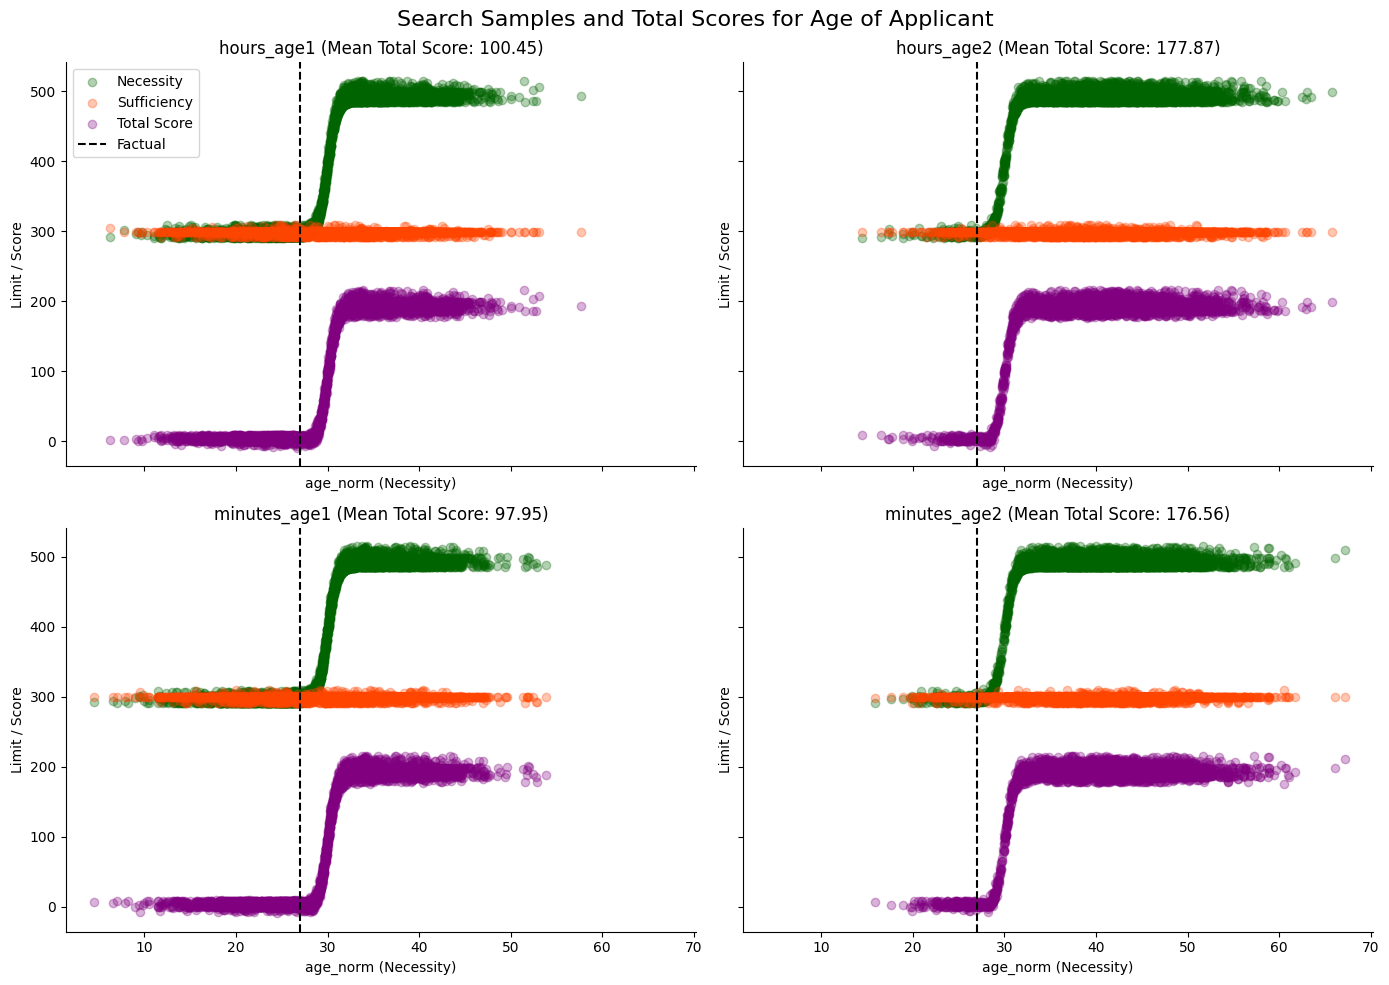

In [22]:
index_of_interest = 250

factuals = {}  # type: ignore

for name, obs in obs_map_for_plotting.items():
    factuals[name] = {}
    for var in obs["continuous"].keys():
        # pick the value at index_of_interest
        factuals[name][var] = obs["continuous"][var][index_of_interest, ...].item()

plot_interventional_scatter(
    all_conditioned_samples=all_conditioned_samples,
    all_suspect_scores=all_suspect_scores,
    factuals=factuals,
    index_of_interest=index_of_interest,
    suspect_of_interest="age_norm",
)

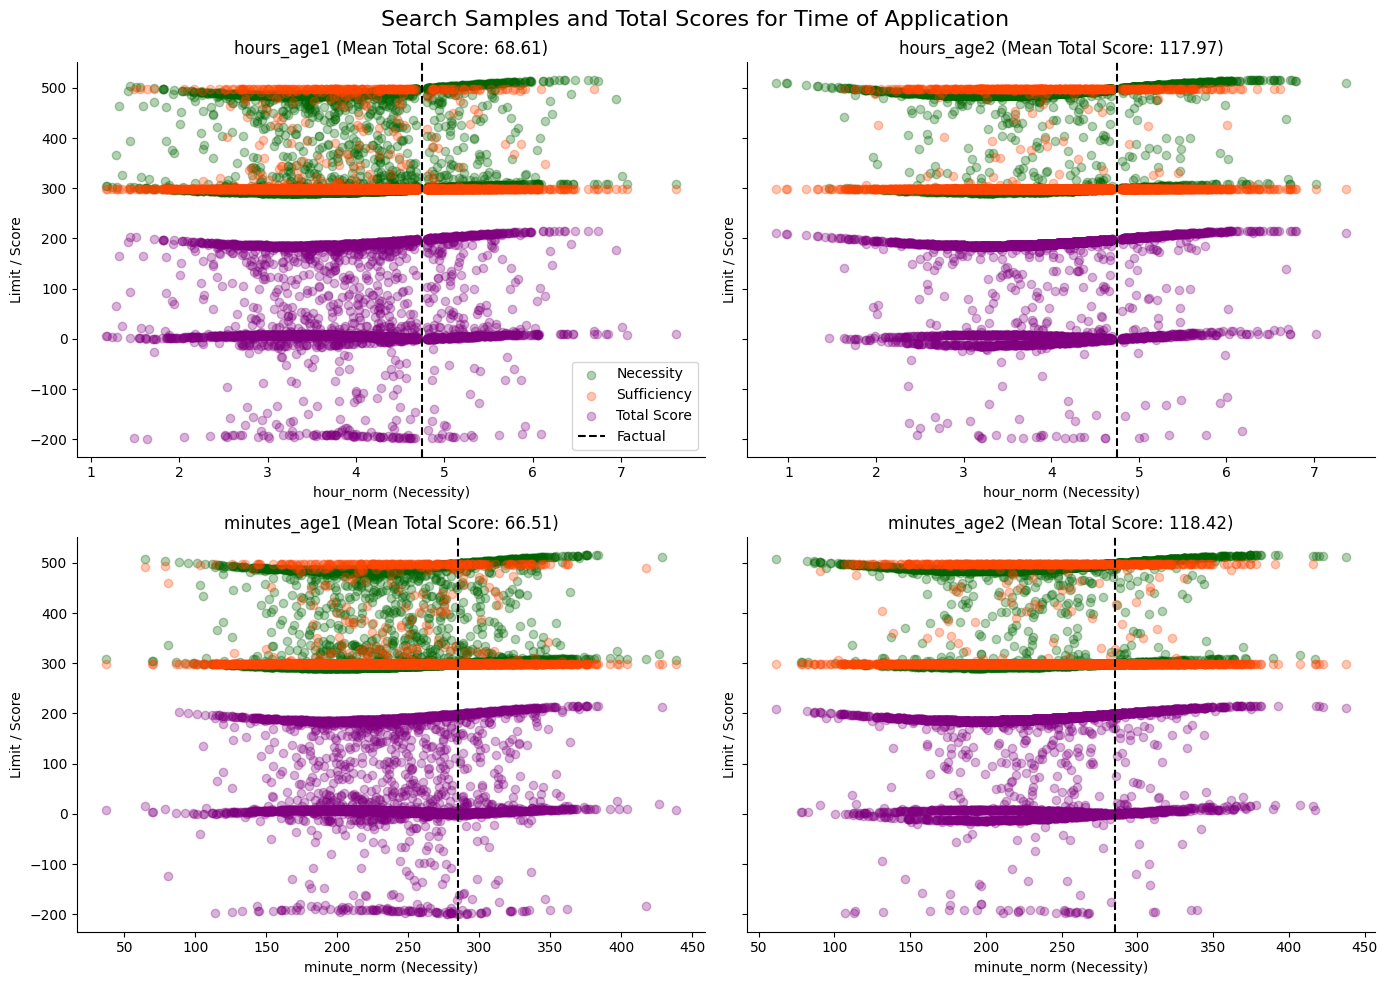

In [23]:
# Plot for hour_norm / minute_norm (auto-handled per model)
plot_interventional_scatter(
    all_conditioned_samples=all_conditioned_samples,
    all_suspect_scores=all_suspect_scores,
    factuals=factuals,
    index_of_interest=index_of_interest,
    suspect_of_interest="hour_norm",
    feature_name="Time of Application",
    sharex=False,  # works for hours, minutes fallback handled
)

In [24]:
# inputs_of_interest
# inputs_of_interest_minutes

print(all_suspect_scores.keys())

mean_total_scores_hours_age_1_age = all_suspect_scores["hours_age1"]["age_norm"][
    "total"
].nanmean(dim=0)
mean_total_scores_hours_age_2_age = all_suspect_scores["hours_age2"]["age_norm"][
    "total"
].nanmean(dim=0)

mean_total_scores_hours_age_1_hour = all_suspect_scores["hours_age1"]["hour_norm"][
    "total"
].nanmean(dim=0)
mean_total_scores_hours_age_2_hour = all_suspect_scores["hours_age2"]["hour_norm"][
    "total"
].nanmean(dim=0)


mean_total_scores_minutes_age_1 = all_suspect_scores["minutes_age1"]["age_norm"][
    "total"
].nanmean(dim=0)
mean_total_scores_minutes_age_2 = all_suspect_scores["minutes_age2"]["age_norm"][
    "total"
].nanmean(dim=0)

mean_total_scores_minutes_age_1_minute = all_suspect_scores["minutes_age1"][
    "minute_norm"
]["total"].nanmean(dim=0)
mean_total_scores_minutes_age_2_minute = all_suspect_scores["minutes_age2"][
    "minute_norm"
]["total"].nanmean(dim=0)


scoring_dict = inputs_of_interest.copy()
scoring_dict_minutes = inputs_of_interest_minutes.copy()

scoring_dict["mean_total_scores_hours_age_1_age"] = mean_total_scores_hours_age_1_age
scoring_dict["mean_total_scores_hours_age_2_age"] = mean_total_scores_hours_age_2_age
scoring_dict["mean_total_scores_hours_age_1_hour"] = mean_total_scores_hours_age_1_hour
scoring_dict["mean_total_scores_hours_age_2_hour"] = mean_total_scores_hours_age_2_hour

scoring_dict_minutes["mean_total_scores_minutes_age_1_age"] = (
    mean_total_scores_minutes_age_1
)
scoring_dict_minutes["mean_total_scores_minutes_age_1_minute"] = (
    mean_total_scores_minutes_age_1_minute
)

scoring_dict_minutes["mean_total_scores_minutes_age_2_age"] = (
    mean_total_scores_minutes_age_2
)
scoring_dict_minutes["mean_total_scores_minutes_age_2_minute"] = (
    mean_total_scores_minutes_age_2_minute
)

scoring_dict = {k: v.flatten().numpy() for k, v in scoring_dict.items()}  # type: ignore
scoring_dict_minutes = {k: v.flatten().numpy() for k, v in scoring_dict_minutes.items()}  # type: ignore

scoring_df_hours = pd.DataFrame(scoring_dict)
scoring_df_minutes = pd.DataFrame(scoring_dict_minutes)

dict_keys(['hours_age1', 'hours_age2', 'minutes_age1', 'minutes_age2'])


In [25]:
print(scoring_df_hours.head())

print(scoring_df_minutes.head())

   age_norm  hour_norm  mean_total_scores_hours_age_1_age  \
0      20.0       0.00                          94.517586   
1      20.0       0.25                          95.747993   
2      20.0       0.50                          96.072365   
3      20.0       0.75                          96.011978   
4      20.0       1.00                          93.545433   

   mean_total_scores_hours_age_2_age  mean_total_scores_hours_age_1_hour  \
0                         172.323456                           64.063408   
1                         171.451141                           66.859779   
2                         170.599274                           65.647232   
3                         172.204391                           63.485779   
4                         173.111710                           62.604679   

   mean_total_scores_hours_age_2_hour  
0                          111.227272  
1                          110.673592  
2                          109.741135  
3               

### <a id='toc2_4_'></a>[Sensitivity to priors, but not to scale](#toc0_)

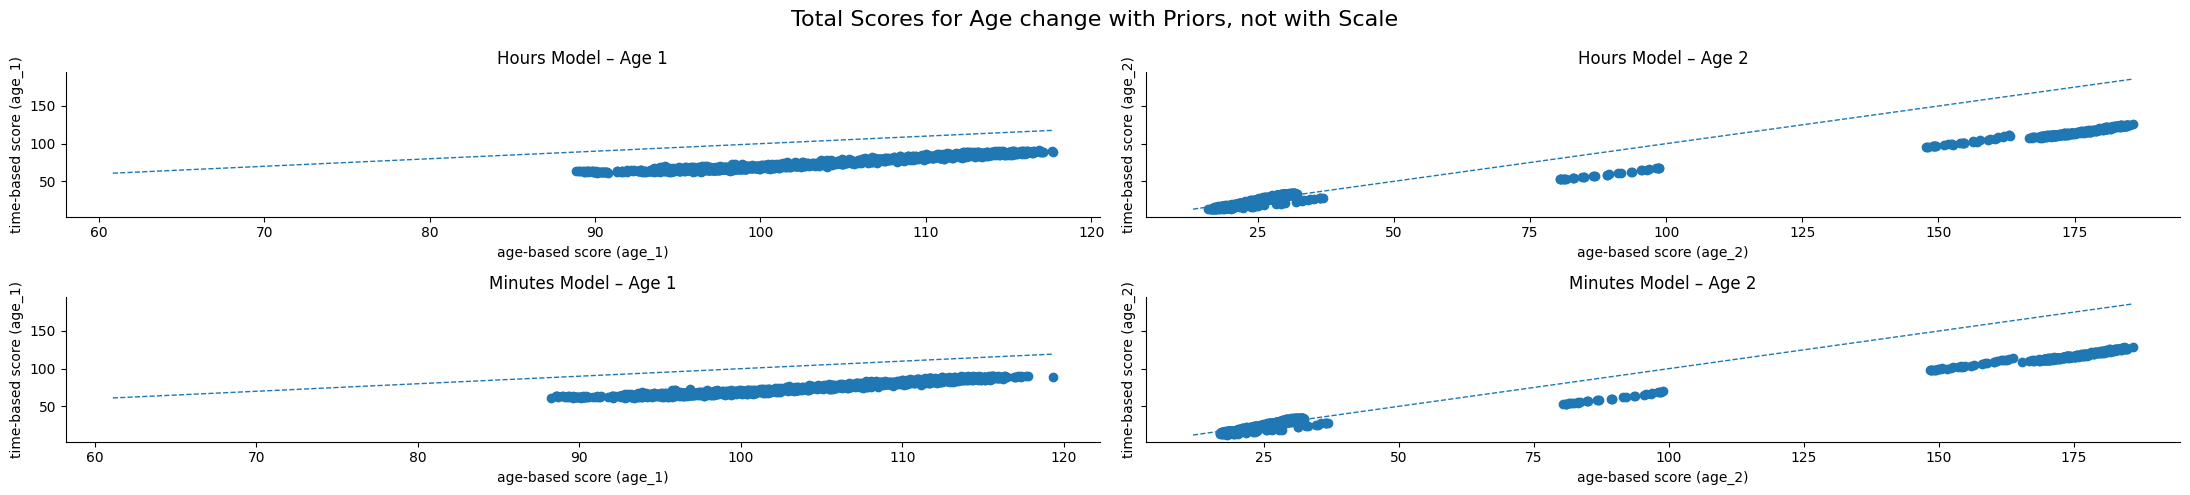

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(22, 5), sharey=True)

axes = axes.flatten()


def add_xy_line(ax, data_x, data_y):
    low = min(data_x.min(), data_y.min())
    high = max(data_x.max(), data_y.max())
    ax.plot([low, high], [low, high], linestyle="--", linewidth=1)


# -------- HOURS DF --------


# subplot 1: age_1 (hours)
x1 = scoring_df_hours["mean_total_scores_hours_age_1_age"]
y1 = scoring_df_hours["mean_total_scores_hours_age_1_hour"]
axes[0].scatter(x1, y1)
add_xy_line(axes[0], x1, y1)
axes[0].set_title("Hours Model – Age 1")
axes[0].set_xlabel("age-based score (age_1)")
axes[0].set_ylabel("time-based score (age_1)")
sns.despine(ax=axes[0])

# subplot 2: age_2 (hours)
x2 = scoring_df_hours["mean_total_scores_hours_age_2_age"]
y2 = scoring_df_hours["mean_total_scores_hours_age_2_hour"]
axes[1].scatter(x2, y2)
add_xy_line(axes[1], x2, y2)
axes[1].set_title("Hours Model – Age 2")
axes[1].set_xlabel("age-based score (age_2)")
axes[1].set_ylabel("time-based score (age_2)")
sns.despine(ax=axes[1])


# -------- MINUTES DF --------

# subplot 3: age_1 (minutes)
x3 = scoring_df_minutes["mean_total_scores_minutes_age_1_age"]
y3 = scoring_df_minutes["mean_total_scores_minutes_age_1_minute"]
axes[2].scatter(x3, y3)
add_xy_line(axes[2], x3, y3)
axes[2].set_title("Minutes Model – Age 1")
axes[2].set_xlabel("age-based score (age_1)")
axes[2].set_ylabel("time-based score (age_1)")
sns.despine(ax=axes[2])

# subplot 4: age_2 (minutes)
x4 = scoring_df_minutes["mean_total_scores_minutes_age_2_age"]
y4 = scoring_df_minutes["mean_total_scores_minutes_age_2_minute"]
axes[3].scatter(x4, y4)
add_xy_line(axes[3], x4, y4)
axes[3].set_title("Minutes Model – Age 2")
axes[3].set_xlabel("age-based score (age_2)")
axes[3].set_ylabel("time-based score (age_2)")
sns.despine(ax=axes[3])

plt.suptitle("Total Scores for Age change with Priors, not with Scale", fontsize=16)

plt.tight_layout()
plt.show()

In [27]:
def plot_diff_contour(
    df,
    time_var,  # "hour_norm" or "minute_norm"
    prefix,  # "hours" or "minutes"
    age_label,  # "age_1" or "age_2"
    levels=15,
):
    """
    df: scoring_df_hours or scoring_df_minutes
    time_var: column storing hour_norm or minute_norm
    prefix: "hours" or "minutes"
    age_label: "age_1" or "age_2"
    """

    # Construct correct column names
    col_age_score = f"mean_total_scores_{prefix}_{age_label}_age"
    col_time_score = f"mean_total_scores_{prefix}_{age_label}_{time_var.split('_')[0]}"

    # Extract values
    score_age = df[col_age_score].values
    score_time = df[col_time_score].values

    ages = df["age_norm"].values
    times = df[time_var].values

    # Reshape into mesh
    unique_ages = np.unique(ages)
    unique_times = np.unique(times)

    nA = len(unique_ages)
    nT = len(unique_times)

    A = ages.reshape(nA, nT)
    T = times.reshape(nA, nT)

    Z_age = score_age.reshape(nA, nT)
    Z_time = score_time.reshape(nA, nT)

    Z_diff = Z_age - Z_time

    # ---- PLOT ----
    plt.figure(figsize=(8, 6))
    cmap = "cividis"

    # Use more levels for smoother shading

    # Filled contour
    cont = plt.contourf(A, T, Z_diff, levels=levels, cmap=cmap)

    # Very thin outer contour lines (optional but clearer)
    plt.contour(A, T, Z_diff, levels=levels, colors="black", linewidths=0.25, alpha=0.4)

    plt.xlabel("Age of Applicant")
    plt.ylabel("Time of Application")
    plt.title(
        "Difference: Age Score − Time of Application Score (hours, age_1)",
    )

    plt.colorbar(cont, label="Difference (Age - Time Score)")

    plt.suptitle(
        "Responsibility of Age is always higher than that of Application Time",
        fontsize=16,
    )

    plt.tight_layout()

    fig_path = f"dce/contour_diff_{prefix}_{age_label}.png"
    plt.savefig(fig_path, dpi=300)

    plt.show()


# TODO generalize to minutes too, perhaps

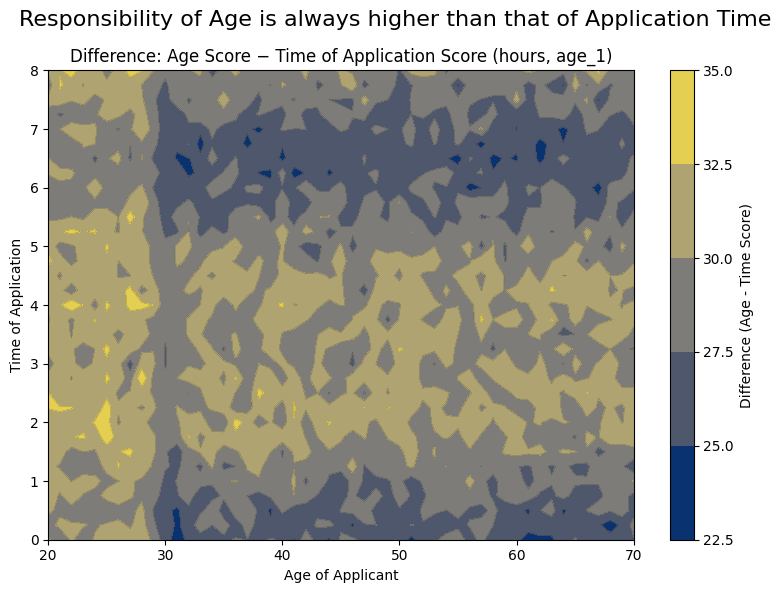

In [28]:
plot_diff_contour(
    scoring_df_hours, time_var="hour_norm", prefix="hours", age_label="age_1", levels=4
)

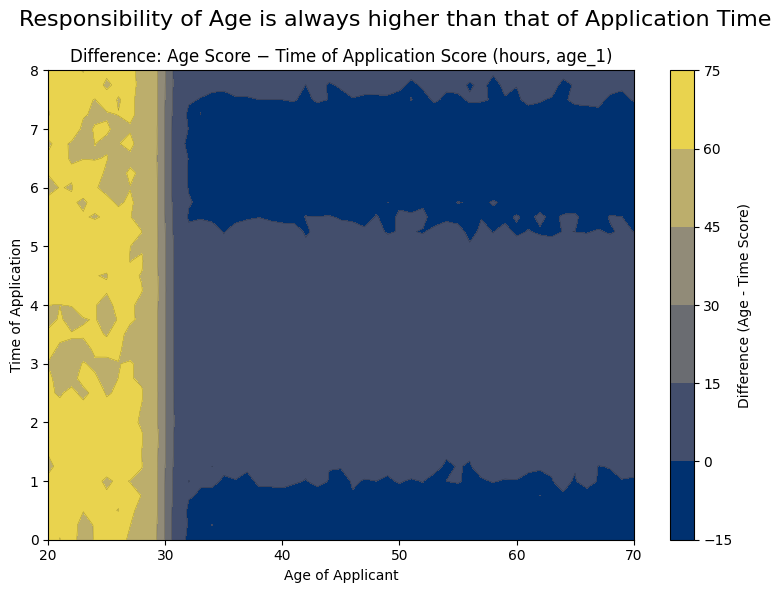

In [29]:
plot_diff_contour(
    scoring_df_hours, time_var="hour_norm", prefix="hours", age_label="age_2", levels=4
)

### <a id='toc2_5_'></a>[Differential Causal Effect](#toc0_)

In [30]:
def add_gradient_scores(df_inputs, model, time_var="hour_norm", grad_prefix="grad"):
    """
    Compute gradients of model output w.r.t age_norm and time_var, and add them to df_inputs.

    Args:
        df_inputs: pd.DataFrame containing 'age_norm' and time_var
        model: callable model(age_tensor, time_tensor)
        time_var: str, either 'hour_norm' or 'minute_norm'
        grad_prefix: prefix for new gradient columns

    Returns:
        pd.DataFrame with gradient columns appended
    """
    age_grad = torch.tensor(
        df_inputs["age_norm"].values, dtype=torch.float32, requires_grad=True
    )
    time_grad = torch.tensor(
        df_inputs[time_var].values, dtype=torch.float32, requires_grad=True
    )

    grads_age = []
    grads_time = []

    N = len(df_inputs)

    for i in range(N):
        age_i = age_grad[i : i + 1]
        time_i = time_grad[i : i + 1]

        out = model(age_i, time_i)

        grad_age, grad_time = torch.autograd.grad(
            outputs=out, inputs=(age_grad, time_grad), retain_graph=True
        )

        grads_age.append(grad_age[i])
        grads_time.append(grad_time[i])

    # Stack and convert to numpy
    grads_age = torch.stack(grads_age).numpy()
    grads_time = torch.stack(grads_time).numpy()

    # Append to DataFrame
    df_inputs[f"{grad_prefix}_age_norm"] = grads_age
    df_inputs[f"{grad_prefix}_{time_var}"] = grads_time

    return df_inputs

In [31]:
# Hours model
scoring_df_hours = add_gradient_scores(
    scoring_df_hours,
    internal_model_hours,
    time_var="hour_norm",
    grad_prefix="grad_hours",
)

# Minutes model
scoring_df_minutes = add_gradient_scores(
    scoring_df_minutes,
    internal_model_minutes,
    time_var="minute_norm",
    grad_prefix="grad_minutes",
)

In [32]:
display(scoring_df_minutes.head())

,age_norm,minute_norm,mean_total_scores_minutes_age_1_age,mean_total_scores_minutes_age_1_minute,mean_total_scores_minutes_age_2_age,mean_total_scores_minutes_age_2_minute,grad_minutes_age_norm,grad_minutes_minute_norm
0,20.0,0.0,95.850647,64.947624,171.312485,112.795670,8.491953e-07,-6.338002e-09
1,20.0,15.0,95.088326,66.667442,169.926147,111.865868,8.484766e-07,-3.469996e-02
2,20.0,30.0,97.548485,68.142998,170.527649,113.504463,8.463622e-07,-6.738329e-02
3,20.0,45.0,95.933380,63.564137,172.359634,113.323616,8.429751e-07,-9.615052e-02
4,20.0,60.0,96.415512,63.972469,172.443634,114.362335,8.385119e-07,-1.193299e-01


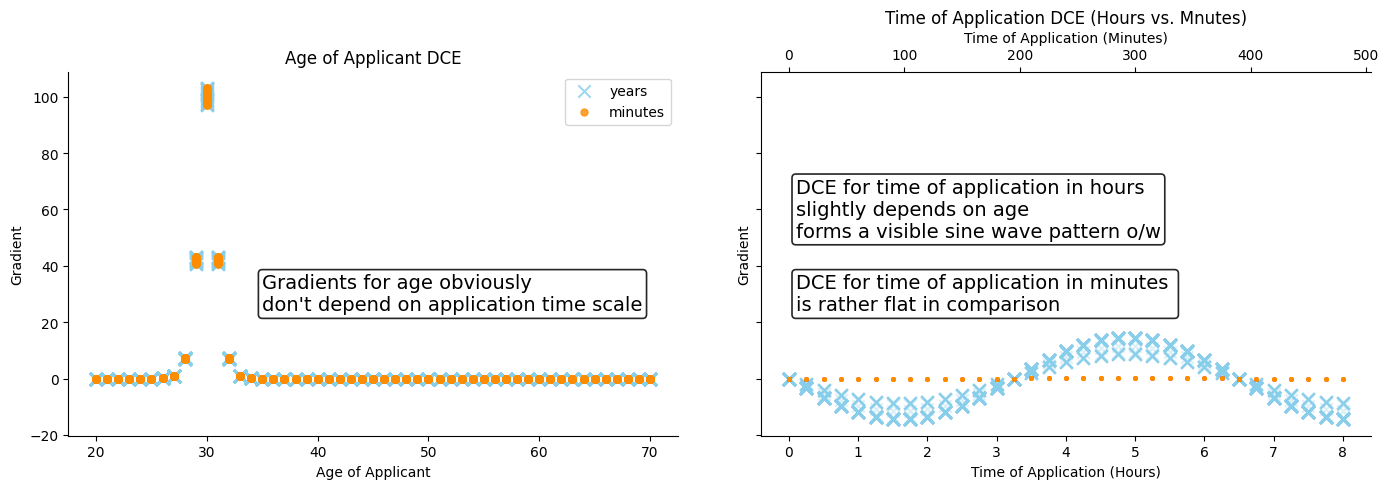

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)


df = scoring_df_hours
age_col = "age_norm"
time_col = "hour_norm"
age_grad_col = "grad_hours_age_norm"
time_grad_col = "grad_hours_hour_norm"


axes[0].scatter(
    df[age_col],
    df[age_grad_col],
    alpha=0.8,
    s=80,
    label="years",
    marker="x",
    color="skyblue",
)
axes[0].set_xlabel("Age of Applicant")
axes[0].set_ylabel("Gradient")
axes[0].set_title("Age of Appplicant (DCE)")
axes[0].legend()


# # --- Subplot 2: Time vs Time Gradient ---
axes[1].scatter(
    df[time_col],
    df[time_grad_col],
    alpha=0.3,
    s=80,
    label="years",
    marker="x",
    color="skyblue",
)
axes[1].set_xlabel("Time of Application (Hours)")
axes[1].set_ylabel("Gradient")
axes[1].set_title("Time of Application DCE (Hours vs. Mnutes)")

add_line_end_label(
    axes[1],
    0.1,
    60,
    "DCE for time of application in hours \nslightly depends on age \nforms a visible sine wave pattern o/w",
)

add_line_end_label(
    axes[1],
    0.1,
    30,
    "DCE for time of application in minutes \nis rather flat in comparison",
)


df = scoring_df_minutes
age_col = "age_norm"
time_col = "minute_norm"
age_grad_col = "grad_minutes_age_norm"
time_grad_col = "grad_minutes_minute_norm"

axes[0].scatter(
    df[age_col], df[age_grad_col], alpha=0.8, s=25, label="minutes", color="darkorange"
)
axes[0].set_ylabel("Gradient")
axes[0].set_title("Age of Applicant DCE")
axes[0].legend()

add_line_end_label(
    axes[0],
    35,
    30,
    "Gradients for age obviously \ndon't depend on application time scale",
)


ax_minutes = axes[1].secondary_xaxis(
    "top",
    functions=(
        lambda h: h * 60,  # convert hours → minutes for tick display
        lambda m: m / 60,  # convert minutes → hours to map coords
    ),
)

ax_minutes.set_xlabel("Time of Application (Minutes)")


# optional: customize the minute ticks
# ax_minutes.set_xticks()


# # --- Subplot 2: Time vs Time Gradient ---
axes[1].scatter(
    df[time_col] / 60,
    df[time_grad_col],
    alpha=0.3,
    s=5,
    label="minutes",
    color="darkorange",
)

sns.despine()
plt.tight_layout()
file_path = "dce/dce_age_time_hours_minutes.png"
plt.savefig(file_path, dpi=300)
plt.show()